# 04_xfg_success_ipw_v2: Corrected Methodology

## Objective
This notebook implements the outcome (success) models for Field Goals, specifically comparing a baseline GLMM (M1) against a Selection-Bias Corrected Model (M2) using Inverse Probability Weighting (IPW).

## Key Methodological Updates (v2)
1.  **Continuous Weights:** M2 now uses raw, continuous Hájek weights (no integer rounding) to properly handle the variance estimation.
2.  **Rationality Check (Path A):** A visualization comparing the predicted success probability of *actual attempts* vs. *non-attempts* to validate the "Rational Coach" hypothesis.
3.  **Tail Calibration (Path B):** Evaluation metrics are specifically broken out for long-distance kicks (50+ yards) to test if IPW improves performance in the high-variance zone.

## Dependencies
* `tidyverse`
* `glmmTMB`
* `splines2`
* `Metrics`
* `calibrationBand` (optional, for plots)

In [42]:
# --- Parameters & Setup ---
PROJECT_ROOT <- sub("[/\\\\][^/\\\\]*$", "", getwd())

data_dir <- file.path(PROJECT_ROOT, 'data')
models_dir <- file.path(PROJECT_ROOT, 'models')
reports_dir <- file.path(PROJECT_ROOT, 'reports')
augmented_dir <- file.path(data_dir, 'augmented')
augmented_reports_dir <- file.path(reports_dir, 'xfg_success_augmented')

SEASONS <- 2015:2024
DIST_KNOTS <- c(28, 38, 48, 58)
DIST_BOUNDS <- c(18, 70)
TEST_RATIO <- 0.30
set.seed(202407) # For reproducible train/test split

# --- Library Imports ---
dependencies <- c(
  'dplyr', 'tibble', 'tidyr', 'readr', 'stringr', 'purrr', 'ggplot2','broom.mixed',
  'splines', 'splines2', 'glmmTMB', 'pROC', 'rlang', 'scales', 'minqa','lme4','patchwork','ggrepel'
)
installed <- rownames(installed.packages())
for (pkg in dependencies) {
  if (!pkg %in% installed) install.packages(pkg)
  suppressPackageStartupMessages(library(pkg, character.only = TRUE))
}

# Set plot theme
theme_set(theme_minimal())
print("Libraries loaded.")

also installing the dependencies 'listenv', 'parallelly', 'future', 'globals', 'coda', 'furrr'




package 'listenv' successfully unpacked and MD5 sums checked
package 'parallelly' successfully unpacked and MD5 sums checked
package 'future' successfully unpacked and MD5 sums checked
package 'globals' successfully unpacked and MD5 sums checked
package 'coda' successfully unpacked and MD5 sums checked
package 'furrr' successfully unpacked and MD5 sums checked
package 'broom.mixed' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\ekerv\AppData\Local\Temp\RtmpwzOION\downloaded_packages
[1] "Libraries loaded."


In [16]:
# ==============================================================================
# 0. Load Libraries & Define Utility Functions
# ==============================================================================
# --- USER PROVIDED UTILITY FUNCTIONS ---

# Distance B-splines using splines2
build_distance_bs <- function(x, knots, bknots, degree = 3, intercept = FALSE) {
  stopifnot(!missing(x), !missing(knots), !missing(bknots))
  if (!requireNamespace("splines2", quietly = TRUE)) stop("Package 'splines2' required")
  bs <- splines2::bSpline(x, knots = knots, Boundary.knots = bknots, degree = degree, intercept = intercept)
  bs <- as.data.frame(bs)
  names(bs) <- paste0("dist_bs_", seq_len(ncol(bs)))
  bs
}

# Loss metrics
brier <- function(y, p) mean((y - p)^2, na.rm = TRUE)
logloss <- function(y, p, eps = 1e-15) -mean(y * log(pmin(pmax(p, eps), 1 - eps)) + (1 - y) * log(1 - pmin(pmax(p, eps), 1 - eps)), na.rm = TRUE)
auc <- function(y, p) {
  keep <- is.finite(p) & is.finite(y)
  if (sum(keep) < 2 || length(unique(y[keep])) < 2) return(NA_real_)
  as.numeric(pROC::auc(y[keep], p[keep], quiet = TRUE))
}

# Safe prediction helper with diagnostics
predict_safe <- function(fit, newdata) {
  if (is.null(fit)) return(rep(NA_real_, nrow(newdata)))
  p_resp <- tryCatch(as.numeric(stats::predict(fit, newdata = newdata, type = "response", allow.new.levels = TRUE)), error = function(e) {
    cat("ERROR in stats::predict:\n")
    cat("Message:", conditionMessage(e), "\n")
    cat("Call:", deparse(conditionCall(e)), "\n")
    NULL
  })
  if (!is.null(p_resp)) return(pmin(pmax(p_resp, 0), 1))
  rep(NA_real_, nrow(newdata))
}

# Pool sparse random effect levels
pool_sparse_levels <- function(train_df, test_df, id_col, min_n = 5L, repl = "REPL", keep_cols = NULL) {
  stopifnot(id_col %in% names(train_df), id_col %in% names(test_df))
  if (!is.null(keep_cols)) {
    train_df <- train_df %>% dplyr::select(dplyr::any_of(keep_cols))
    test_df  <- test_df  %>% dplyr::select(dplyr::any_of(keep_cols))
  }
  tab <- table(train_df[[id_col]])
  keep_levels <- names(tab)[tab >= min_n]
  train_df[[id_col]] <- ifelse(train_df[[id_col]] %in% keep_levels, as.character(train_df[[id_col]]), repl)
  test_df[[id_col]]  <- ifelse(test_df[[id_col]] %in% keep_levels, as.character(test_df[[id_col]]), repl)
  all_levels <- unique(c(train_df[[id_col]], test_df[[id_col]]))
  train_df[[id_col]] <- factor(train_df[[id_col]], levels = all_levels)
  test_df[[id_col]]  <- factor(test_df[[id_col]], levels = all_levels)
  list(train = train_df, test = test_df)
}

# --- 1. Redefine Metric Helper Function (Ensures latest version is active) ---
calc_metrics <- function(y, p, set_name, threshold = 0.5) {
  # specific requires
  requireNamespace("Metrics", quietly = TRUE)
  requireNamespace("pROC", quietly = TRUE)
  
  # Filter for validity
  valid <- is.finite(p) & is.finite(y)
  y <- y[valid]
  p <- p[valid]
  
  # --- Probabilistic Metrics ---
  val_brier <- mean((y - p)^2)
  val_ll    <- Metrics::logLoss(y, p)
  
  # AUC (Safe calculation)
  val_auc <- if (length(unique(y)) < 2) NA_real_ else as.numeric(pROC::auc(y, p, quiet = TRUE))
  
  # Calibration Error (L1)
  cal_df <- tibble::tibble(y = y, p = p) %>%
    dplyr::mutate(bin = dplyr::ntile(p, 10)) %>%
    dplyr::group_by(bin) %>%
    dplyr::summarise(mean_pred = mean(p), mean_obs = mean(y), .groups="drop") %>%
    dplyr::mutate(diff = abs(mean_pred - mean_obs))
  val_calib <- mean(cal_df$diff, na.rm=TRUE)
  
  # --- Classification Metrics (at threshold) ---
  pred_class <- ifelse(p >= threshold, 1, 0)
  
  TP <- sum(y == 1 & pred_class == 1)
  TN <- sum(y == 0 & pred_class == 0)
  FP <- sum(y == 0 & pred_class == 1)
  FN <- sum(y == 1 & pred_class == 0)
  
  val_acc <- (TP + TN) / length(y)
  
  # Handle division by zero for Precision/Recall
  val_prec <- if ((TP + FP) > 0) TP / (TP + FP) else 0.0
  val_rec  <- if ((TP + FN) > 0) TP / (TP + FN) else 0.0
  val_f1   <- if ((val_prec + val_rec) > 0) 2 * (val_prec * val_rec) / (val_prec + val_rec) else 0.0
  
  # Return structured tibble
  tibble::tibble(
    set = set_name,
    brier = val_brier,
    logloss = val_ll,
    auc = val_auc,
    calib_error = val_calib,
    accuracy = val_acc,
    precision = val_prec,
    recall = val_rec,
    f1_score = val_f1
  )
}

# --- 2. Define Control Settings ---
ctrl <- glmmTMB::glmmTMBControl(
  optimizer = nlminb, 
  optCtrl = list(iter.max = 1000, eval.max = 1000),
  parallel = 6
)

## 1. Data Loading & Preparation

We load the dataset prepared in `03_attempt_pi.ipynb`, which should contain:
* `kick_made`: Binary outcome (1/0)
* `weight_multinom_hajek`: The continuous IPW weights
* `attempt_fg`: Flag for attempts vs non-attempts

In [17]:
# ==============================================================================
# 1. Data Loading, Cleaning & Feature Engineering (Consolidated & Complete)
# ==============================================================================

# --- A. Define Paths & Load Raw Data ---
fg_path       <- file.path(data_dir, 'fg_all.csv')
kicker_path   <- file.path(data_dir, 'kicker_by_game.csv')
oof_path      <- file.path(reports_dir, 'attempt_pi', 'attempt_pi_oof_predictions_final.csv')
test_ids_path <- file.path(augmented_dir, 'test_fg_game_ids.csv')

# Fail fast if files are missing
stopifnot(file.exists(fg_path), file.exists(kicker_path), file.exists(oof_path))

fg_all         <- readr::read_csv(fg_path, show_col_types = FALSE)
kicker_by_game <- readr::read_csv(kicker_path, show_col_types = FALSE)
preds_oof      <- readr::read_csv(oof_path, show_col_types = FALSE)

# --- B. Coerce Keys for Consistent Joins ---
fg_all <- fg_all %>% 
  dplyr::mutate(
    season = as.integer(season),
    game_id = as.character(game_id), 
    play_id = as.character(play_id),
    team_for_join = toupper(posteam)
  )

kicker_by_game <- kicker_by_game %>% 
  dplyr::mutate(game_id = as.character(game_id), team = as.character(team))

preds_oof <- preds_oof %>% 
  dplyr::mutate(
    season = as.integer(season),
    game_id = as.character(game_id), 
    play_id = as.character(play_id)
  ) %>%
  dplyr::select(season, game_id, play_id, p_hat_attempt_clipped, w_ipw_final)

# --- C. Filter Universe & Impute Kicker IDs ---
# We keep Attempts (FG/PAT) AND Non-Attempts (Run/Pass/Punt) in the 18-70y range
fg_base <- fg_all %>%
  dplyr::filter(
    as.character(season) %in% as.character(SEASONS),
    play_type_original %in% c('field_goal', 'extra_point', 'pass', 'run', 'punt'),
    kick_distance >= 18 & kick_distance <= 70,
    kick_result != 'blocked' | is.na(kick_result)
  ) %>%
  # Join Kicker IDs (crucial for Non-Attempts)
  dplyr::left_join(
    kicker_by_game %>% dplyr::select(game_id, team, kg_kicker_player_id = kicker_player_id), 
    by = c("game_id" = "game_id", "team_for_join" = "team")
  ) %>%
  dplyr::mutate(
    kicker_player_id = dplyr::coalesce(kicker_player_id, kg_kicker_player_id),
    kicker_player_id = as.factor(ifelse(kicker_player_id == "NA", NA, kicker_player_id)),
    # Define Types
    is_pat = as.integer(play_type_original == 'extra_point'),
    is_fg  = as.integer(play_type_original == 'field_goal'),
    is_non = as.integer(!play_type_original %in% c('field_goal', 'extra_point'))
  ) %>%
  dplyr::select(-kg_kicker_player_id) %>%
  # Join Propensity Scores & Weights
  dplyr::left_join(preds_oof, by = c('season', 'game_id', 'play_id'))

# --- C-2. Impute Age & Experience (Integrated Fix) ---
# 1. Build Reference Table from Actual Attempts (where age/exp exists)
kicker_ref <- fg_base %>%
  dplyr::filter(!is.na(kicker_age), !is.na(kicker_experience)) %>%
  dplyr::group_by(season, kicker_player_id) %>%
  dplyr::summarise(
    ref_age = mean(kicker_age, na.rm = TRUE),
    ref_exp = mean(kicker_experience, na.rm = TRUE),
    .groups = "drop"
  )

# 2. Join Ref and Coalesce (Fills Non-Attempts with Kicker's Seasonal Avg)
fg_base <- fg_base %>%
  dplyr::left_join(kicker_ref, by = c("season", "kicker_player_id")) %>%
  dplyr::mutate(
    kicker_age = dplyr::coalesce(kicker_age, ref_age),
    kicker_experience = dplyr::coalesce(kicker_experience, ref_exp)
  ) %>%
  dplyr::select(-ref_age, -ref_exp)

# 3. Global Fallback (For kickers with 0 attempts in a season)
league_medians <- fg_base %>%
  dplyr::group_by(season) %>%
  dplyr::summarise(
    med_age = median(kicker_age, na.rm = TRUE),
    med_exp = median(kicker_experience, na.rm = TRUE),
    .groups = "drop"
  )

fg_base <- fg_base %>%
  dplyr::left_join(league_medians, by = "season") %>%
  dplyr::mutate(
    kicker_age = dplyr::coalesce(kicker_age, med_age),
    kicker_experience = dplyr::coalesce(kicker_experience, med_exp)
  ) %>%
  dplyr::select(-med_age, -med_exp)

# 4. Calculate Z-Scores (Standardized on Attempts Only)
stats_params <- fg_base %>%
  dplyr::filter(is_fg == 1 | is_pat == 1) %>%
  dplyr::summarise(
    mean_age = mean(kicker_age, na.rm = TRUE),
    sd_age   = sd(kicker_age, na.rm = TRUE),
    mean_exp = mean(kicker_experience, na.rm = TRUE),
    sd_exp   = sd(kicker_experience, na.rm = TRUE)
  )

fg_base <- fg_base %>%
  dplyr::mutate(
    kicker_age_z = (kicker_age - stats_params$mean_age) / stats_params$sd_age,
    kicker_experience_z = (kicker_experience - stats_params$mean_exp) / stats_params$sd_exp
  )

# --- D. Generate Splines (For ALL rows) ---
# We do this BEFORE splitting so Non-Attempts get the exact same features
if(exists("build_distance_bs") && exists("DIST_KNOTS")) {
  dist_splines <- build_distance_bs(fg_base$kick_distance, knots = DIST_KNOTS, bknots = DIST_BOUNDS)
  fg_base <- dplyr::bind_cols(fg_base, dist_splines)
} else {
  warning("Spline function not found. Ensure 'build_distance_bs' is loaded.")
}

# --- E. Handle Weights & Probabilities (The "Frankenstein" Merge) ---
# 1. Calculate Reference Stats from Field Goals Only
fg_ref <- fg_base %>% dplyr::filter(is_fg == 1L)

p_hat_vec <- fg_ref$p_hat_attempt_clipped
max_p_hat_fg <- max(p_hat_vec[!is.na(p_hat_vec)], na.rm = TRUE)
if(!is.finite(max_p_hat_fg)) max_p_hat_fg <- 0.99

wvec_ipw <- fg_ref$w_ipw_final
min_ipw_w_fg <- min(wvec_ipw[!is.na(wvec_ipw)], na.rm = TRUE)
if(!is.finite(min_ipw_w_fg)) min_ipw_w_fg <- 1.0

# 2. Assign Weights to Everything (FG, PAT, NON)
fg_base <- fg_base %>%
  dplyr::mutate(
    # Fallback for missing p_hat (e.g. if OOF missing for some non-attempts)
    p_hat_attempt_clipped = ifelse(is.na(p_hat_attempt_clipped), 0.01, p_hat_attempt_clipped),
    
    # Construct Canonical Probability
    p_hat_multinom = dplyr::case_when(
      is_pat == 1L ~ as.numeric(max_p_hat_fg),
      TRUE ~ as.numeric(p_hat_attempt_clipped)
    ),
    
    # Construct Canonical Weight
    # FGs: Use OOF IPW
    # PATs: Use Min FG Weight
    # Non-Attempts: Use OOF IPW if exists, else 1/p_hat
    weight_multinom_hajek = dplyr::case_when(
      is_pat == 1L ~ as.numeric(min_ipw_w_fg),
      !is.na(w_ipw_final) ~ as.numeric(w_ipw_final), 
      TRUE ~ 1 / p_hat_multinom 
    ),
    
    # Standardize Outcome (Target)
    kick_made = dplyr::case_when(
      kick_result %in% c('made', 'good') ~ 1L,
      TRUE ~ 0L
    )
  )

# --- F. Create Master Sets & Splits ---
FG_master  <- fg_base %>% dplyr::filter(is_fg == 1L)
PAT_master <- fg_base %>% dplyr::filter(is_pat == 1L)
NON_master <- fg_base %>% dplyr::filter(is_non == 1L)

# Train/Test Split on FGs
if (file.exists(test_ids_path)) {
  test_game_ids <- readr::read_csv(test_ids_path, show_col_types = FALSE) %>% dplyr::pull(game_id)
  train_game_ids <- setdiff(unique(FG_master$game_id), test_game_ids)
  
  train_df <- FG_master %>% dplyr::filter(game_id %in% train_game_ids)
  test_df  <- FG_master %>% dplyr::filter(game_id %in% test_game_ids)
  
  message(sprintf("Data Ready:\nTrain FGs: %d | Test FGs: %d\nNon-Attempts (for Rationality Plot): %d", 
                  nrow(train_df), nrow(test_df), nrow(NON_master)))
} else {
  stop("Test IDs file missing.")
}

Data Ready:
Train FGs: 7238 | Test FGs: 3194
Non-Attempts (for Rationality Plot): 9981



In [18]:
glimpse(NON_master)

Rows: 9,981
Columns: 106
$ game_id                    <chr> "2015_01_CAR_JAX", "2015_01_CAR_JAX", "2015…
$ play_id                    <chr> "1900", "2508", "3200", "385", "749", "1008…
$ old_game_id                <dbl> 2015091302, 2015091302, 2015091302, 2015091…
$ season                     <int> 2015, 2015, 2015, 2015, 2015, 2015, 2015, 2…
$ week                       <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ season_type                <chr> "REG", "REG", "REG", "REG", "REG", "REG", "…
$ playoffs                   <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ qtr                        <dbl> 2, 3, 4, 1, 1, 2, 4, 4, 4, 1, 2, 4, 4, 1, 4…
$ game_date                  <date> 2015-09-13, 2015-09-13, 2015-09-13, 2015-0…
$ home_team                  <chr> "JAX", "JAX", "JAX", "LV", "LV", "LV", "LV"…
$ away_team                  <chr> "CAR", "CAR", "CAR", "CIN", "CIN", "CIN", "…
$ posteam                    <chr> "CAR", "CAR", "CAR", "CIN", "CIN", "LV", "L…
$ defteam      


--- IPW Weight Statistics ---


# A tibble: 1 × 8
  Total_N Min_W Median_W Mean_W Max_W  SD_W   ESS ESS_Ratio
    <int> <dbl>    <dbl>  <dbl> <dbl> <dbl> <dbl>     <dbl>
1   10432 0.617    0.698  0.944  8.55 0.875 5612.     0.538
Interpretation: ESS_Ratio < 1.0 is normal. If < 0.10, weights are too unstable.


`geom_smooth()` using formula = 'y ~ x'



--- Top 10 Most Heavily Weighted Attempts ---
# A tibble: 10 × 9
   season posteam kick_distance  wind_z score_differential   qtr
    <int> <chr>           <dbl>   <dbl>              <dbl> <dbl>
 1   2017 NO                 56  0.0502                 14     4
 2   2017 BAL                62  0.0502                -19     2
 3   2017 ATL                59 -1.03                   17     2
 4   2017 DEN                53 -0.130                 -14     2
 5   2017 NE                 62 -1.03                   14     2
 6   2017 GB                 57  0.230                   7     3
 7   2017 LA                 63 -0.850                   7     2
 8   2024 DAL                65 -1.03                   -7     1
 9   2024 MIN                58 -1.03                   24     4
10   2024 KC                 65 -1.03                   -3     2
   game_seconds_remaining weight_multinom_hajek kick_made
                    <dbl>                 <dbl>     <int>
 1                    542             

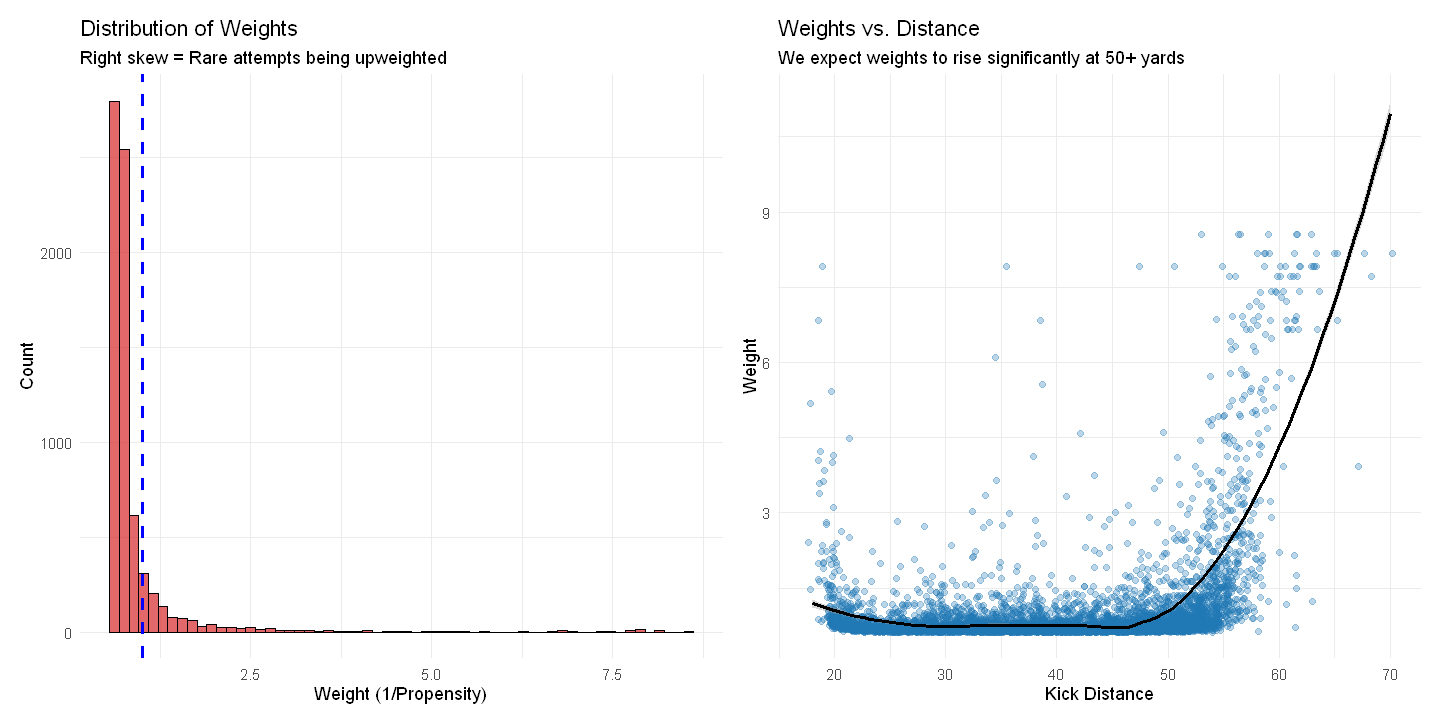

In [52]:
# Note: 'patchwork' is already loaded earlier in the notebook (see cell 1).
# Avoid re-loading libraries in this cell to prevent duplicate imports.

# --- 1. Statistical Summary ---
weight_stats <- FG_master %>%
  summarise(
    Total_N = n(),
    Min_W = min(weight_multinom_hajek),
    Median_W = median(weight_multinom_hajek),
    Mean_W = mean(weight_multinom_hajek), # Should be approx 1.0
    Max_W = max(weight_multinom_hajek),
    SD_W = sd(weight_multinom_hajek),
    # Kish's Effective Sample Size (ESS) formula
    ESS = (sum(weight_multinom_hajek)^2) / sum(weight_multinom_hajek^2),
    ESS_Ratio = ESS / Total_N
  )

cat("\n--- IPW Weight Statistics ---\n")
print(weight_stats)
cat("Interpretation: ESS_Ratio < 1.0 is normal. If < 0.10, weights are too unstable.\n")

# --- 2. Visualizations ---

# A. Histogram: What does the weight distribution look like?
p1 <- ggplot(train_df, aes(x = weight_multinom_hajek)) +
  geom_histogram(bins = 60, fill = "#d62728", color = "black", alpha = 0.7) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "blue", size = 1) +
  labs(
    title = "Distribution of Weights",
    subtitle = "Right skew = Rare attempts being upweighted",
    x = "Weight (1/Propensity)", 
    y = "Count"
  ) +
  theme_minimal()

# B. Weights vs. Distance: Is it fixing the range bias?
p2 <- ggplot(train_df, aes(x = kick_distance, y = weight_multinom_hajek)) +
  geom_jitter(alpha = 0.3, width = 0.5, color = "#1f77b4") +
  geom_smooth(method = "loess", color = "black", se = TRUE) +
  labs(
    title = "Weights vs. Distance",
    subtitle = "We expect weights to rise significantly at 50+ yards",
    x = "Kick Distance", 
    y = "Weight"
  ) +
  theme_minimal()

# C. Weights vs. Wind: Is it fixing environmental bias?
p3 <- ggplot(train_df, aes(x = wind_z, y = weight_multinom_hajek)) +
  geom_point(alpha = 0.3, color = "#2ca02c") +
  geom_smooth(method = "loess", color = "black") +
  labs(
    title = "Weights vs. Wind (Z-Score)",
    subtitle = "Are high-wind kicks getting higher importance?",
    x = "Wind Speed (Standardized)", 
    y = "Weight"
  ) +
  theme_minimal()

# Combine and Display
# Set figure size for notebook output
options(repr.plot.width = 12, repr.plot.height = 6)

# Combine p1 and p2 side-by-side with p3 below them using patchwork.
# Use explicit print() to ensure rendering in non-interactive contexts.
combined <- (p1 | p2)
print(combined)

# --- 3. The "Unicorns": Top Weighted Plays ---
# These are the kicks the model is told to "pay extra attention to"
top_weighted_plays <- train_df %>%
  arrange(desc(weight_multinom_hajek)) %>%
  select(season, posteam, kick_distance, wind_z, score_differential, qtr, game_seconds_remaining, weight_multinom_hajek, kick_made) %>%
  head(10)
options(tibble.width = Inf)
cat("\n--- Top 10 Most Heavily Weighted Attempts ---\n")
print(top_weighted_plays)

## 2. Model M1: Baseline Success Model
Standard GLMM using `glmmTMB`. This serves as the benchmark.

In [20]:
# 5. Load M1 model to get formula and predict xFG for NON_master
m1_model_path <- file.path(models_dir, "m1", "m1_fg_B_logit.rds")
if (!file.exists(m1_model_path)) stop("M1 model not found. Run 04_xfg_success_ipw.ipynb first.")
m1_saved_model <- readRDS(m1_model_path)
m1_formula <- formula(m1_saved_model)
m1_formula

m0_model_path <- file.path(models_dir, "m0", "m0_fg_B_logit.rds")
if (!file.exists(m0_model_path)) stop("M0 model not found. Run 04_xfg_success_ipw.ipynb first.")
m0_saved_model <- readRDS(m0_model_path)
m0_formula <- formula(m0_saved_model)
m0_formula


# Fit M1 (Unweighted)
print("Fitting M1 (Baseline)...")
fit_m1 <- glmmTMB(
    formula = m1_formula,
    data = train_df,
    family = binomial(link = "logit"),
    control = ctrl
)

summary(fit_m1)

kick_made ~ dist_bs_1 + dist_bs_2 + dist_bs_3 + dist_bs_4 + dist_bs_5 + 
    dist_bs_6 + dist_bs_7 + wind_z * temp_z + indoors + high_altitude + 
    is_rain_showers + is_snow_sleet + is_ot + iced + clock_running * 
    posteam_timeouts_remaining + kicker_age_z:kicker_experience_z + 
    (dist_bs_1):wind_z + (dist_bs_2):wind_z + (dist_bs_3):wind_z + 
    (dist_bs_4):wind_z + (dist_bs_5):wind_z + (dist_bs_6):wind_z + 
    (dist_bs_7):wind_z + (dist_bs_1):temp_z + (dist_bs_2):temp_z + 
    (dist_bs_3):temp_z + (dist_bs_4):temp_z + (dist_bs_5):temp_z + 
    (dist_bs_6):temp_z + (dist_bs_7):temp_z + (1 | stadium_id) + 
    (1 | season:kicker_player_id)
<environment: 0x000002207676d238>

kick_made ~ dist_bs_1 + dist_bs_2 + dist_bs_3 + dist_bs_4 + dist_bs_5 + 
    dist_bs_6 + dist_bs_7
<environment: 0x0000022079b223c0>

[1] "Fitting M1 (Baseline)..."


 Family: binomial  ( logit )
Formula:          
kick_made ~ dist_bs_1 + dist_bs_2 + dist_bs_3 + dist_bs_4 + dist_bs_5 +  
    dist_bs_6 + dist_bs_7 + wind_z * temp_z + indoors + high_altitude +  
    is_rain_showers + is_snow_sleet + is_ot + iced + clock_running *  
    posteam_timeouts_remaining + kicker_age_z:kicker_experience_z +  
    (dist_bs_1):wind_z + (dist_bs_2):wind_z + (dist_bs_3):wind_z +  
    (dist_bs_4):wind_z + (dist_bs_5):wind_z + (dist_bs_6):wind_z +  
    (dist_bs_7):wind_z + (dist_bs_1):temp_z + (dist_bs_2):temp_z +  
    (dist_bs_3):temp_z + (dist_bs_4):temp_z + (dist_bs_5):temp_z +  
    (dist_bs_6):temp_z + (dist_bs_7):temp_z + (1 | stadium_id) +  
    (1 | season:kicker_player_id)
Data: train_df

      AIC       BIC    logLik -2*log(L)  df.resid 
   5033.5    5288.3   -2479.7    4959.5      7201 

Random effects:

Conditional model:
 Groups                  Name        Variance Std.Dev.
 stadium_id              (Intercept) 0.01489  0.1220  
 season:kicker_player

In [23]:
# Load M1 model to get the full formula
m1_model_path <- file.path(models_dir, "m1", "m1_fg_B_logit.rds")
if (!file.exists(m1_model_path)) stop("M1 model not found.")
m1_saved_model <- readRDS(m1_model_path)
m1_formula <- formula(m1_saved_model)

# Pool sparse random effect levels
pool_full <- pool_sparse_levels(FG_master, FG_master[1:5,], id_col = "kicker_player_id", min_n = 5L)
fg_pooled <- pool_full$train

# --- 1. Fit Full M1 ---
print("Fitting Full M1 on pooled FG_master...")
fit_m1_full <- glmmTMB(
    formula = m1_formula,
    data = fg_pooled,
    family = binomial(link = "logit"),
    control = ctrl
)
summary(fit_m1_full)

# --- 2. Modify Formula (The Robust Way) ---
# Get all terms as character strings
all_terms <- labels(terms(m1_formula))

# Identify Random Effects (contain "|") and wrap them in parentheses
# This fixes the "model frame mismatch" error
is_re <- grepl("|", all_terms, fixed = TRUE)
all_terms[is_re] <- paste0("(", all_terms[is_re], ")")

# Define terms to drop
# Note: Ensure these match the exact strings in 'all_terms'
terms_to_drop <- c("indoors", "high_altitude", "kicker_age_z:kicker_experience_z")

# Filter terms
modified_terms <- all_terms[!all_terms %in% terms_to_drop]

# Reconstruct Formula
modified_formula_str <- paste("kick_made ~", paste(modified_terms, collapse = " + "))
modified_formula <- as.formula(modified_formula_str)

cat("\nModified Formula:\n")
print(modified_formula)

# --- 3. Fit Modified M1 ---
print("Fitting Modified M1 (dropped terms) on pooled FG_master...")
fit_m1_modified <- glmmTMB(
    formula = modified_formula,
    data = fg_pooled,
    family = binomial(link = "logit"),
    control = ctrl
)
summary(fit_m1_modified)

[1] "Fitting Full M1 on pooled FG_master..."


 Family: binomial  ( logit )
Formula:          
kick_made ~ dist_bs_1 + dist_bs_2 + dist_bs_3 + dist_bs_4 + dist_bs_5 +  
    dist_bs_6 + dist_bs_7 + wind_z * temp_z + indoors + high_altitude +  
    is_rain_showers + is_snow_sleet + is_ot + iced + clock_running *  
    posteam_timeouts_remaining + kicker_age_z:kicker_experience_z +  
    (dist_bs_1):wind_z + (dist_bs_2):wind_z + (dist_bs_3):wind_z +  
    (dist_bs_4):wind_z + (dist_bs_5):wind_z + (dist_bs_6):wind_z +  
    (dist_bs_7):wind_z + (dist_bs_1):temp_z + (dist_bs_2):temp_z +  
    (dist_bs_3):temp_z + (dist_bs_4):temp_z + (dist_bs_5):temp_z +  
    (dist_bs_6):temp_z + (dist_bs_7):temp_z + (1 | stadium_id) +  
    (1 | season:kicker_player_id)
Data: fg_pooled

      AIC       BIC    logLik -2*log(L)  df.resid 
   7073.7    7342.0   -3499.8    6999.7     10395 

Random effects:

Conditional model:
 Groups                  Name        Variance Std.Dev.
 stadium_id              (Intercept) 0.01872  0.1368  
 season:kicker_playe


Modified Formula:
kick_made ~ dist_bs_1 + dist_bs_2 + dist_bs_3 + dist_bs_4 + dist_bs_5 + 
    dist_bs_6 + dist_bs_7 + wind_z + temp_z + is_rain_showers + 
    is_snow_sleet + is_ot + iced + clock_running + posteam_timeouts_remaining + 
    (1 | stadium_id) + (1 | season:kicker_player_id) + wind_z:temp_z + 
    clock_running:posteam_timeouts_remaining + dist_bs_1:wind_z + 
    dist_bs_2:wind_z + dist_bs_3:wind_z + dist_bs_4:wind_z + 
    dist_bs_5:wind_z + dist_bs_6:wind_z + dist_bs_7:wind_z + 
    dist_bs_1:temp_z + dist_bs_2:temp_z + dist_bs_3:temp_z + 
    dist_bs_4:temp_z + dist_bs_5:temp_z + dist_bs_6:temp_z + 
    dist_bs_7:temp_z
[1] "Fitting Modified M1 (dropped terms) on pooled FG_master..."


 Family: binomial  ( logit )
Formula:          
kick_made ~ dist_bs_1 + dist_bs_2 + dist_bs_3 + dist_bs_4 + dist_bs_5 +  
    dist_bs_6 + dist_bs_7 + wind_z + temp_z + is_rain_showers +  
    is_snow_sleet + is_ot + iced + clock_running + posteam_timeouts_remaining +  
    (1 | stadium_id) + (1 | season:kicker_player_id) + wind_z:temp_z +  
    clock_running:posteam_timeouts_remaining + dist_bs_1:wind_z +  
    dist_bs_2:wind_z + dist_bs_3:wind_z + dist_bs_4:wind_z +  
    dist_bs_5:wind_z + dist_bs_6:wind_z + dist_bs_7:wind_z +  
    dist_bs_1:temp_z + dist_bs_2:temp_z + dist_bs_3:temp_z +  
    dist_bs_4:temp_z + dist_bs_5:temp_z + dist_bs_6:temp_z +  
    dist_bs_7:temp_z
Data: fg_pooled

      AIC       BIC    logLik -2*log(L)  df.resid 
   7072.1    7318.7   -3502.0    7004.1     10398 

Random effects:

Conditional model:
 Groups                  Name        Variance Std.Dev.
 stadium_id              (Intercept) 0.0219   0.1480  
 season:kicker_player_id (Intercept) 0.1130   0.33

In [24]:
# Generate predictions for full M1
p_m1_full <- predict_safe(fit_m1_full, fg_pooled)

# Generate predictions for modified M1
p_m1_modified <- predict_safe(fit_m1_modified, fg_pooled)

# Calculate metrics for full M1
res_m1_full <- calc_metrics(fg_pooled$kick_made, p_m1_full, set_name = "Full M1 (In-Sample)")

# Calculate metrics for modified M1
res_m1_modified <- calc_metrics(fg_pooled$kick_made, p_m1_modified, set_name = "Modified M1 (In-Sample)")

# Combine and display
comparison <- bind_rows(res_m1_full, res_m1_modified)
print(comparison)

# A tibble: 2 × 9
  set         brier logloss   auc calib_error accuracy precision recall f1_score
  <chr>       <dbl>   <dbl> <dbl>       <dbl>    <dbl>     <dbl>  <dbl>    <dbl>
1 Full M1 (I… 0.101   0.325 0.807      0.0163    0.865     0.867  0.996    0.927
2 Modified M… 0.101   0.325 0.808      0.0155    0.864     0.866  0.996    0.927


## 3. Visualization: The "Rationality" Check (Path A)
Before fitting M2, we test the hypothesis that coaches are rational actors. We predict the success probability of the **Non-Attempts** using our baseline model M1.

* **Hypothesis:** Non-attempts should have significantly lower predicted success rates than actual attempts.
* **Implication:** If true, selection bias is driven by "Rational Filtering," and the lack of overlap explains why IPW might struggle globally.

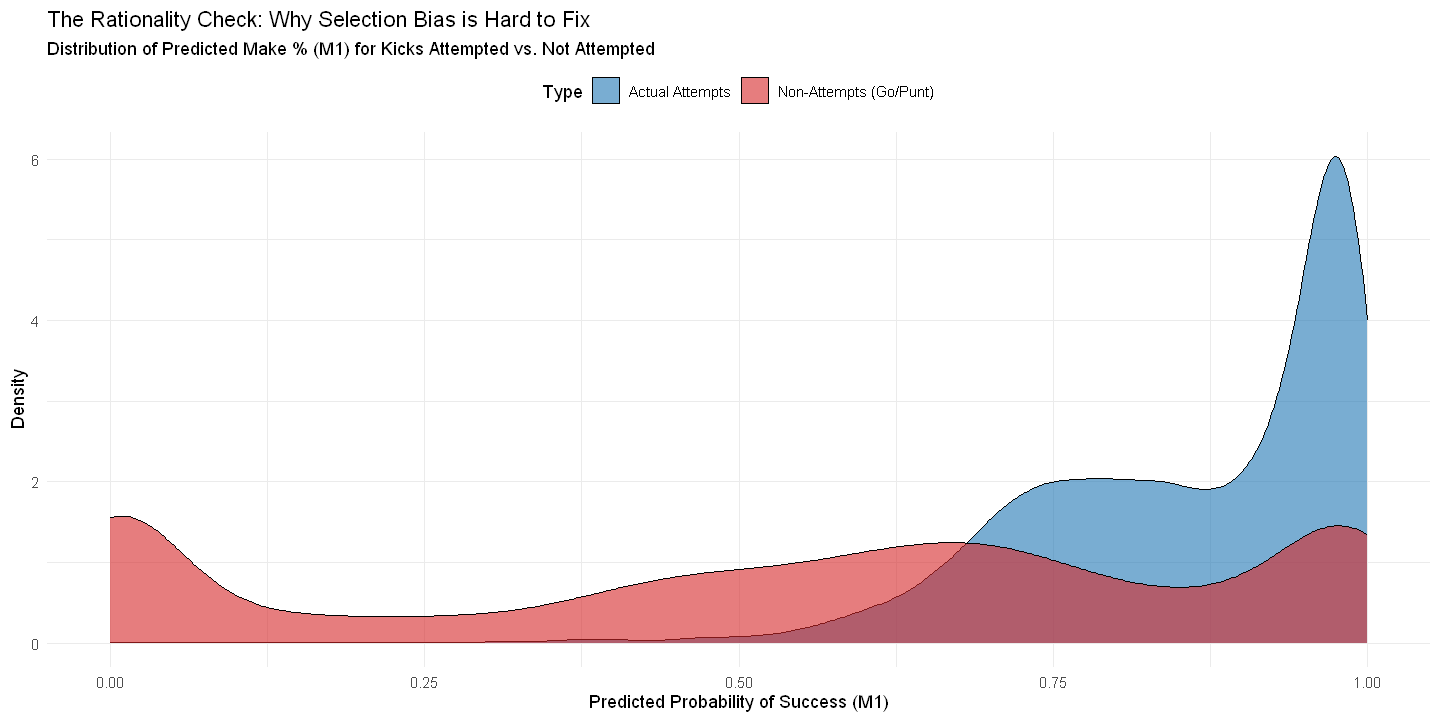

In [25]:
# 1. Predict on Actual Attempts (Train set)
train_df$pred_prob_m1 <- predict(fit_m1_modified, newdata = train_df, type = "response", allow.new.levels = TRUE)

# 2. Predict on Non-Attempts
# Handle Missing REs: If a kicker/stadium in non_attempts wasn't in train, we allow new levels (RE = 0)
NON_master$pred_prob_m1 <- predict(fit_m1_modified, newdata = NON_master, type = "response", allow.new.levels = TRUE)
# 3. Combine for Plotting
plot_data <- bind_rows(
    train_df %>% select(pred_prob_m1) %>% mutate(Type = "Actual Attempts"),
    NON_master %>% select(pred_prob_m1) %>% mutate(Type = "Non-Attempts (Go/Punt)")
)

# 4. Generate Density Plot
ggplot(plot_data, aes(x = pred_prob_m1, fill = Type)) +
    geom_density(alpha = 0.6) +
    scale_fill_manual(values = c("Actual Attempts" = "#1f77b4", "Non-Attempts (Go/Punt)" = "#d62728")) +
    labs(
        title = "The Rationality Check: Why Selection Bias is Hard to Fix",
        subtitle = "Distribution of Predicted Make % (M1) for Kicks Attempted vs. Not Attempted",
        x = "Predicted Probability of Success (M1)",
        y = "Density"
    ) +
    theme_minimal() +
    theme(legend.position = "top")

## 4. Model M2: IPW Corrected (The Critical Fix)
We now fit the IPW model. 

**CRITICAL CHANGE:** We use `weight_multinom_hajek` directly as continuous weights. We do **not** round to integers. This ensures standard errors reflect the weighting scheme (inverse variance) rather than artificially inflating sample size.

In [28]:
# Check weights distribution before fitting
summary(train_df$weight_multinom_hajek)

print("Fitting M1 Modified on train data")
fit_m1 <- glmmTMB(
    formula = modified_formula,
    data = train_df,
    family = binomial(link = "logit"),
    control = ctrl
)

print("Fitting M2 (Continuous IPW Weights)...")
fit_m2 <- glmmTMB(
    formula = modified_formula,
    data = train_df,
    family = binomial(link = "logit"),
    weights = weight_multinom_hajek,
    control = ctrl
)

summary(fit_m2)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.6168  0.6615  0.6984  0.9488  0.8334  8.5529 

[1] "Fitting M1 Modified on train data"


[1] "Fitting M2 (Continuous IPW Weights)..."


Warning message in eval(family$initialize):
"non-integer #successes in a binomial glm!"


 Family: binomial  ( logit )
Formula:          
kick_made ~ dist_bs_1 + dist_bs_2 + dist_bs_3 + dist_bs_4 + dist_bs_5 +  
    dist_bs_6 + dist_bs_7 + wind_z + temp_z + is_rain_showers +  
    is_snow_sleet + is_ot + iced + clock_running + posteam_timeouts_remaining +  
    (1 | stadium_id) + (1 | season:kicker_player_id) + wind_z:temp_z +  
    clock_running:posteam_timeouts_remaining + dist_bs_1:wind_z +  
    dist_bs_2:wind_z + dist_bs_3:wind_z + dist_bs_4:wind_z +  
    dist_bs_5:wind_z + dist_bs_6:wind_z + dist_bs_7:wind_z +  
    dist_bs_1:temp_z + dist_bs_2:temp_z + dist_bs_3:temp_z +  
    dist_bs_4:temp_z + dist_bs_5:temp_z + dist_bs_6:temp_z +  
    dist_bs_7:temp_z
Data: train_df
Weights: weight_multinom_hajek

      AIC       BIC    logLik -2*log(L)  df.resid 
   5383.1    5617.2   -2657.5    5315.1      7204 

Random effects:

Conditional model:
 Groups                  Name        Variance Std.Dev.
 stadium_id              (Intercept) 0.09923  0.3150  
 season:kicker_playe

## 5. Evaluation: The Tail Calibration (Path B)
Standard global metrics (AUC/Brier) are often dominated by the high volume of short, easy kicks. To see the value of M2, we must look at the "High Difficulty" subset.

We evaluate on two cuts of the Test Data:
1.  **Global:** All test kicks.
2.  **Tail (50+):** Only kicks >= 50 yards.

In [50]:
# Load required libraries
if(!require(Metrics)) install.packages("Metrics")
library(Metrics)
library(dplyr)
library(pROC)

# --- Generate Predictions for Test Set ---
# Ensure test_df is prepared (rows filtered, features present)
test_df$pred_m1 <- predict(fit_m1, newdata = test_df, type = "response", allow.new.levels = TRUE)
test_df$pred_m2 <- predict(fit_m2, newdata = test_df, type = "response", allow.new.levels = TRUE)

# --- 1. Global Evaluation ---
df_m1 <- test_df %>% mutate(pred = pred_m1)
df_m2 <- test_df %>% mutate(pred = pred_m2)

global_res <- bind_rows(
    calc_metrics(df_m1$kick_made, df_m1$pred, "M1 (Global)"),
    calc_metrics(df_m2$kick_made, df_m2$pred, "M2 (Global)")
)

# --- 2. Tail Evaluation (>= 50 Yards) ---
# The "High Variance" Zone
subset_50 <- test_df %>% filter(kick_distance >= 50)

df_m1_50 <- subset_50 %>% mutate(pred = pred_m1)
df_m2_50 <- subset_50 %>% mutate(pred = pred_m2)

tail_res <- bind_rows(
    calc_metrics(df_m1_50$kick_made, df_m1_50$pred, "M1 (50+ yds)"),
    calc_metrics(df_m2_50$kick_made, df_m2_50$pred, "M2 (50+ yds)")
)

# --- 3. Decision Zone Evaluation (30% - 70% Win Prob) ---
# The "Overlap" Zone where decisions are hardest
subset_zone <- test_df %>% filter(pred_m1 >= 0.25 & pred_m1 <= 0.75)

df_m1_zone <- subset_zone %>% mutate(pred = pred_m1)
df_m2_zone <- subset_zone %>% mutate(pred = pred_m2)

zone_res <- bind_rows(
    calc_metrics(df_m1_zone$kick_made, df_m1_zone$pred, "M1 (Zone 25-75%)"),
    calc_metrics(df_m2_zone$kick_made, df_m2_zone$pred, "M2 (Zone 25-75%)")
)

# Combine and Display
final_results <- bind_rows(global_res, tail_res, zone_res)
print(final_results)

#Save to csv
output_path <- file.path(reports_dir, 'xfg_success_ipw', "m1_m2_test_comparison_results.csv")
readr::write_csv(final_results, output_path)
print(paste("Results saved to:", output_path))

# A tibble: 6 × 9
  set               brier logloss   auc calib_error accuracy precision recall
  <chr>             <dbl>   <dbl> <dbl>       <dbl>    <dbl>     <dbl>  <dbl>
1 M1 (Global)      0.0975   0.322 0.772      0.0178    0.876     0.879  0.995
2 M2 (Global)      0.100    0.331 0.760      0.0274    0.872     0.882  0.986
3 M1 (50+ yds)     0.188    0.561 0.653      0.0803    0.737     0.746  0.970
4 M2 (50+ yds)     0.193    0.572 0.641      0.0764    0.717     0.752  0.912
5 M1 (Zone 25-75%) 0.201    0.591 0.568      0.0498    0.715     0.726  0.972
6 M2 (Zone 25-75%) 0.206    0.603 0.571      0.0732    0.697     0.731  0.917
  f1_score
     <dbl>
1    0.934
2    0.931
3    0.843
4    0.824
5    0.831
6    0.814
[1] "Results saved to: x:/My Files/Python/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/xfg_success_ipw/m1_m2_test_comparison_results.csv"


In [30]:
# --- 3. Full In-Sample Evaluation (M1 vs M2 on FG_master) ---
cat("\n--- Running Full In-Sample Evaluation (FG_master) ---\n")

# Prepare Data (Pooling Sparse Levels on the Full Set)
# We use FG_master as both 'train' and 'test' for this check
# Create a dummy test set just to satisfy the function signature
pool_full <- pool_sparse_levels(FG_master, FG_master[1:5,], id_col = "kicker_player_id", min_n = 5L)
fg_full_pooled <- pool_full$train

# Ensure Weights are numeric (Safety check)
fg_full_pooled$weight_multinom_hajek <- as.numeric(fg_full_pooled$weight_multinom_hajek)

# --- Fit Models on Full Data ---
# A. M0: Distance only

cat("Fitting M0 (Distance Only) on full data...\n")
fit_m0_full <- glmmTMB::glmmTMB(
  formula = m0_formula,
  data = fg_full_pooled,
  family = binomial(link = "logit"),
  control = ctrl
)
# B. M1: Baseline (Unweighted)
cat("Fitting M1 (Baseline) on full data...\n")
fit_m1_full <- glmmTMB::glmmTMB(
  formula = modified_formula,
  data = fg_full_pooled,
  family = binomial(link = "logit"),
  control = ctrl
)

# C. M2: IPW Corrected (Weighted)
cat("Fitting M2 (IPW) on full data...\n")
fit_m2_full <- glmmTMB::glmmTMB(
  formula = modified_formula,
  data = fg_full_pooled,
  family = binomial(link = "logit"),
  weights = weight_multinom_hajek,
  control = ctrl
)

# --- Evaluation ---

# Predict
cat("Generating predictions...\n")

p_m0_full <- predict_safe(fit_m0_full, fg_full_pooled)
p_m1_full <- predict_safe(fit_m1_full, fg_full_pooled)
p_m2_full <- predict_safe(fit_m2_full, fg_full_pooled)

# Calculate Metrics
res_m0_full <- calc_metrics(fg_full_pooled$kick_made, p_m0_full, set_name = "in_sample") %>%
  dplyr::mutate(Model = "M0 (Distance Only Full)", .before = 1)

res_m1_full <- calc_metrics(fg_full_pooled$kick_made, p_m1_full, set_name = "in_sample") %>%
  dplyr::mutate(Model = "M1 (Baseline Full)", .before = 1)

res_m2_full <- calc_metrics(fg_full_pooled$kick_made, p_m2_full, set_name = "in_sample") %>%
  dplyr::mutate(Model = "M2 (IPW Full)", .before = 1)

# Compare & Save
insample_comparison <- dplyr::bind_rows(res_m0_full, res_m1_full, res_m2_full) %>%
  dplyr::mutate(
    auc_delta   = auc - res_m1_full$auc,
    brier_delta = brier - res_m1_full$brier,
    calib_delta = calib_error - res_m1_full$calib_error
  )

cat("\n--- Final In-Sample Comparison Results ---\n")
print(insample_comparison)

# Optional: Save for report
if(exists("augmented_reports_dir")) {
  readr::write_csv(insample_comparison, file.path(reports_dir, 'xfg_success_ipw','ipw_insample_comparison.csv'))
}

#Save probabilities for further analysis
fg_full_pooled <- fg_full_pooled %>%
  dplyr::mutate(
    pred_m0_full = p_m0_full,
    pred_m1_full = p_m1_full,
    pred_m2_full = p_m2_full
  )

if(exists("augmented_dir")) {
  readr::write_csv(fg_full_pooled, file.path(reports_dir, 'xfg_success_ipw','fg_full_with_ipw_predictions.csv'))
}


--- Running Full In-Sample Evaluation (FG_master) ---
Fitting M0 (Distance Only) on full data...


Fitting M1 (Baseline) on full data...
Fitting M2 (IPW) on full data...


Warning message in eval(family$initialize):
"non-integer #successes in a binomial glm!"


Generating predictions...

--- Final In-Sample Comparison Results ---
# A tibble: 3 × 13
  Model         set    brier logloss   auc calib_error accuracy precision recall
  <chr>         <chr>  <dbl>   <dbl> <dbl>       <dbl>    <dbl>     <dbl>  <dbl>
1 M0 (Distance… in_s… 0.105    0.340 0.775     0.00684    0.863     0.865  0.997
2 M1 (Baseline… in_s… 0.101    0.325 0.808     0.0155     0.864     0.866  0.996
3 M2 (IPW Full) in_s… 0.0985   0.321 0.808     0.0119     0.871     0.874  0.994
# ℹ 4 more variables: f1_score <dbl>, auc_delta <dbl>, brier_delta <dbl>,
#   calib_delta <dbl>



--- Extracting and Comparing Coefficients (Fixed Effects) ---

--- Top 10 Coefficient Shifts (M1 -> M2) ---
# A tibble: 10 × 7
   term             M1_Baseline_estimate M2_IPW_estimate M1_Baseline_std.error
   <chr>                           <dbl>           <dbl>                 <dbl>
 1 dist_bs_7                      -27.7           -38.1                  12.1 
 2 dist_bs_7:temp_z                 3.98            8.68                  9.67
 3 dist_bs_1                      -11.7           -16.3                   5.95
 4 dist_bs_7:wind_z               -10.4            -5.96                  8.81
 5 dist_bs_5                      -14.8           -19.2                   5.41
 6 dist_bs_3                      -13.4           -17.3                   5.42
 7 (Intercept)                     15.4            19.2                   5.36
 8 dist_bs_4                      -14.6           -18.0                   5.34
 9 dist_bs_2                      -11.5           -14.5                   5.22
10 

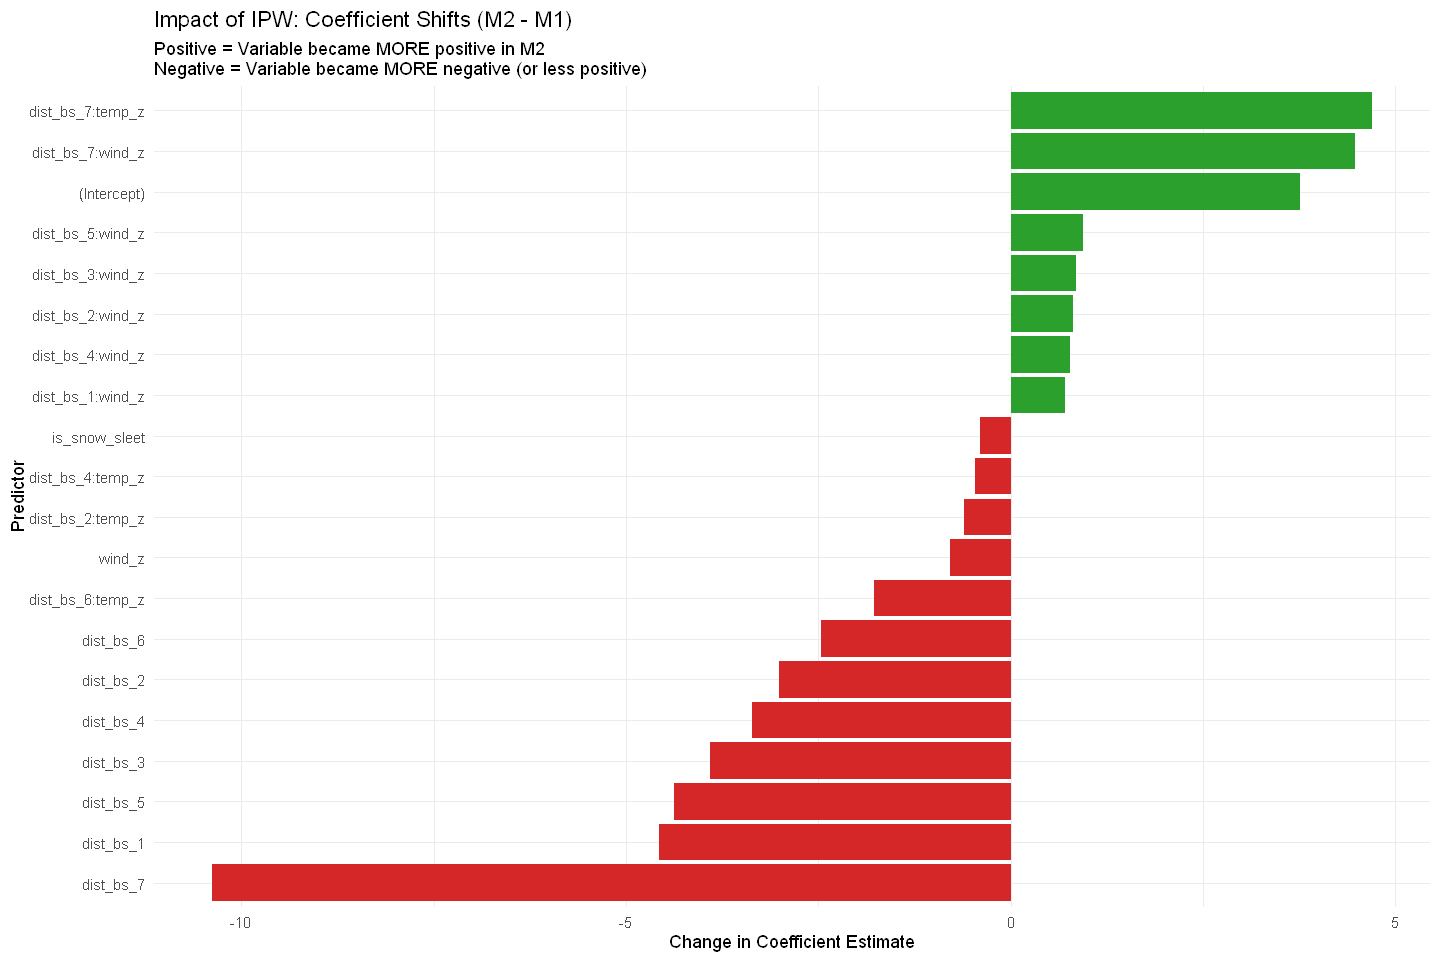

In [43]:
# --- 4. Coefficient Comparison (M1 vs M2) ---
cat("\n--- Extracting and Comparing Coefficients (Fixed Effects) ---\n")

# Helper to extract fixed effects as a tidy dataframe
get_fixed_effects <- function(model, model_name) {
  broom::tidy(model, effects = "fixed") %>%
    dplyr::select(term, estimate, std.error, statistic, p.value) %>%
    dplyr::mutate(model = model_name)
}

# Extract for M1 and M2
coefs_m1 <- get_fixed_effects(fit_m1_full, "M1_Baseline")
coefs_m2 <- get_fixed_effects(fit_m2_full, "M2_IPW")

# Combine and Pivot Wider for side-by-side comparison
coef_comparison <- dplyr::bind_rows(coefs_m1, coefs_m2) %>%
  dplyr::select(term, model, estimate, std.error) %>%
  tidyr::pivot_wider(
    names_from = model,
    values_from = c(estimate, std.error),
    names_glue = "{model}_{.value}"
  ) %>%
  dplyr::mutate(
    # Calculate the shift in coefficients
    coef_shift = M2_IPW_estimate - M1_Baseline_estimate,
    # Calculate the ratio of standard errors (Did weighting inflate variance?)
    se_ratio = M2_IPW_std.error / M1_Baseline_std.error
  ) %>%
  dplyr::arrange(desc(abs(coef_shift))) # Sort by biggest change

# Print Top Changes
cat("\n--- Top 10 Coefficient Shifts (M1 -> M2) ---\n")
print(head(coef_comparison, 10))

# Save Full Table
if(exists("augmented_reports_dir")) {
  readr::write_csv(coef_comparison, file.path(reports_dir, 'xfg_success_ipw', 'm1_vs_m2_coefficient_comparison.csv'))
  cat("Coefficient comparison table saved.\n")
}

# Optional: Visualizing the Shift
# This plot shows which variables became MORE or LESS important after weighting
library(ggplot2)

p_coef_shift <- ggplot(coef_comparison %>% head(20), aes(x = reorder(term, coef_shift), y = coef_shift)) +
  geom_bar(stat = "identity", fill = ifelse(coef_comparison$coef_shift[1:20] > 0, "#2ca02c", "#d62728")) +
  coord_flip() +
  labs(
    title = "Impact of IPW: Coefficient Shifts (M2 - M1)",
    subtitle = "Positive = Variable became MORE positive in M2\nNegative = Variable became MORE negative (or less positive)",
    x = "Predictor",
    y = "Change in Coefficient Estimate"
  ) +
  theme_minimal()

print(p_coef_shift)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


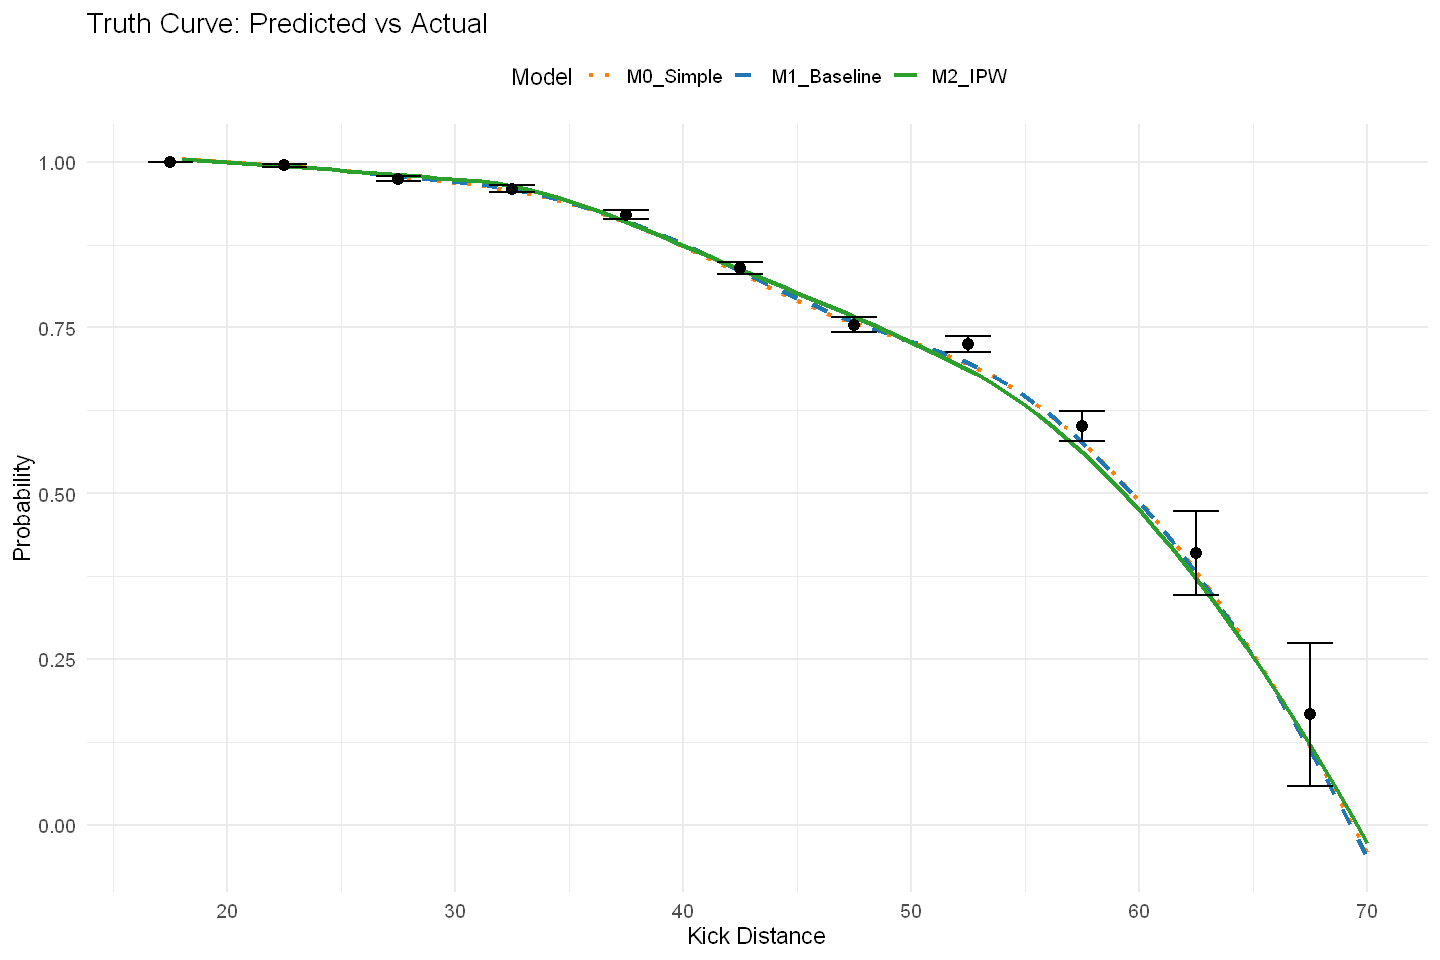

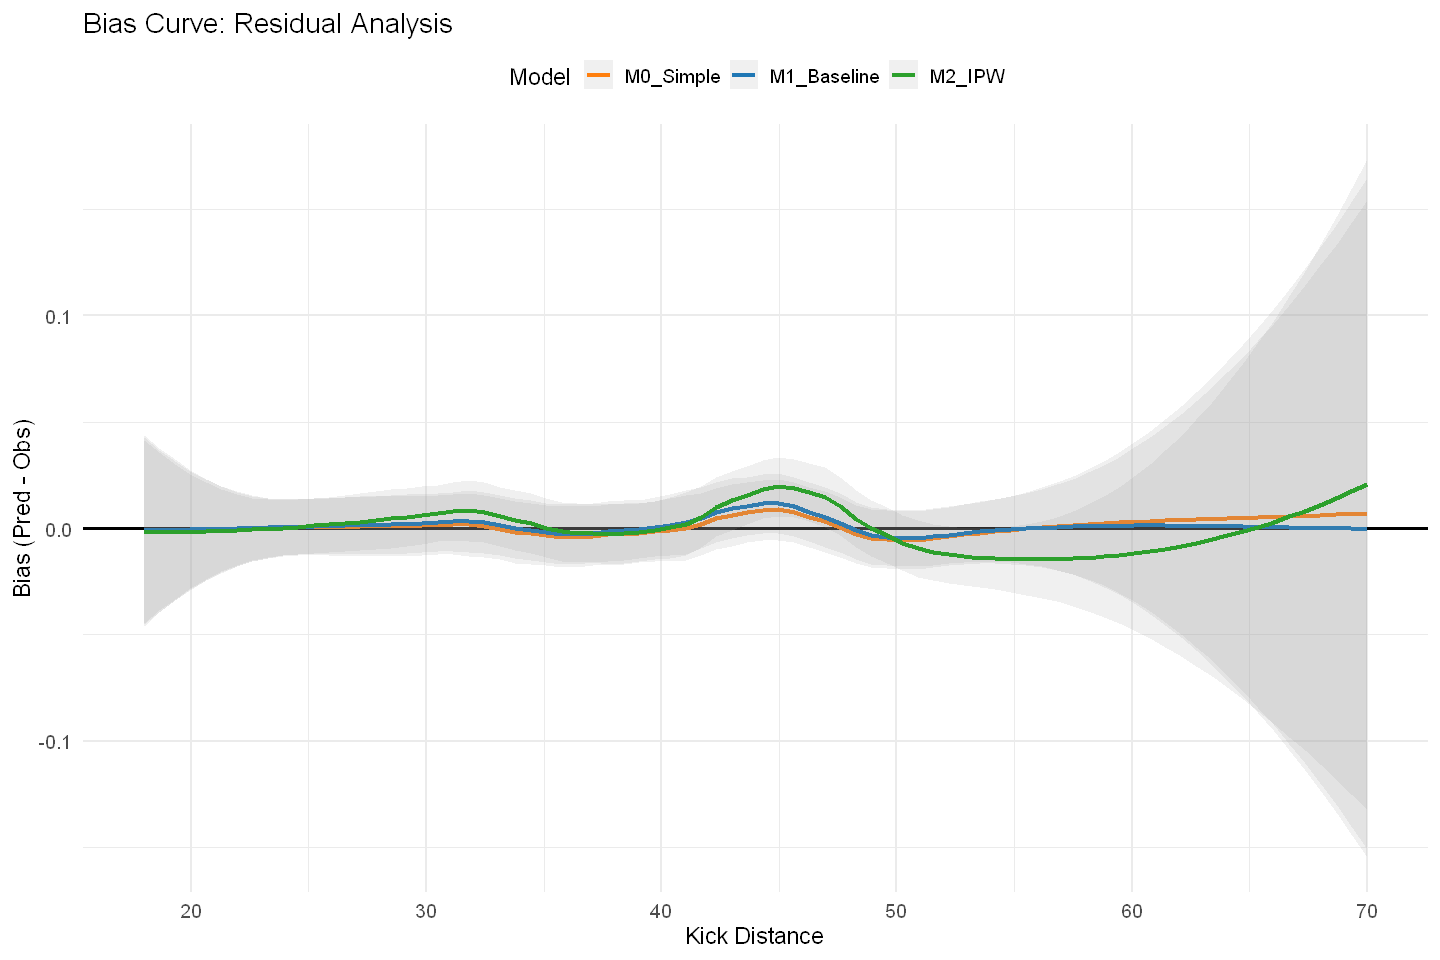

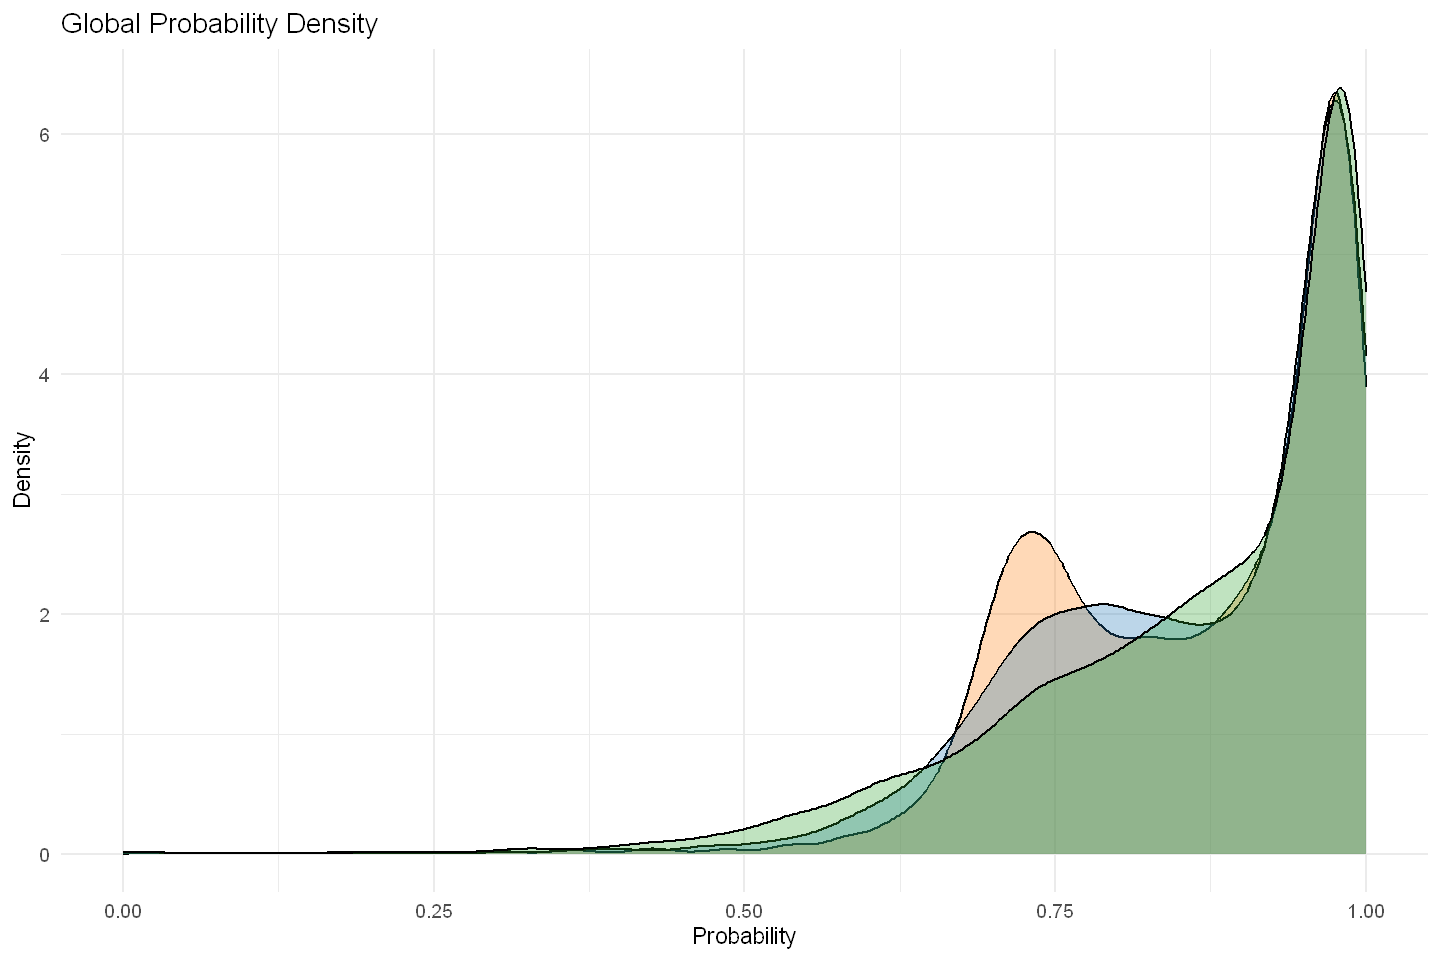

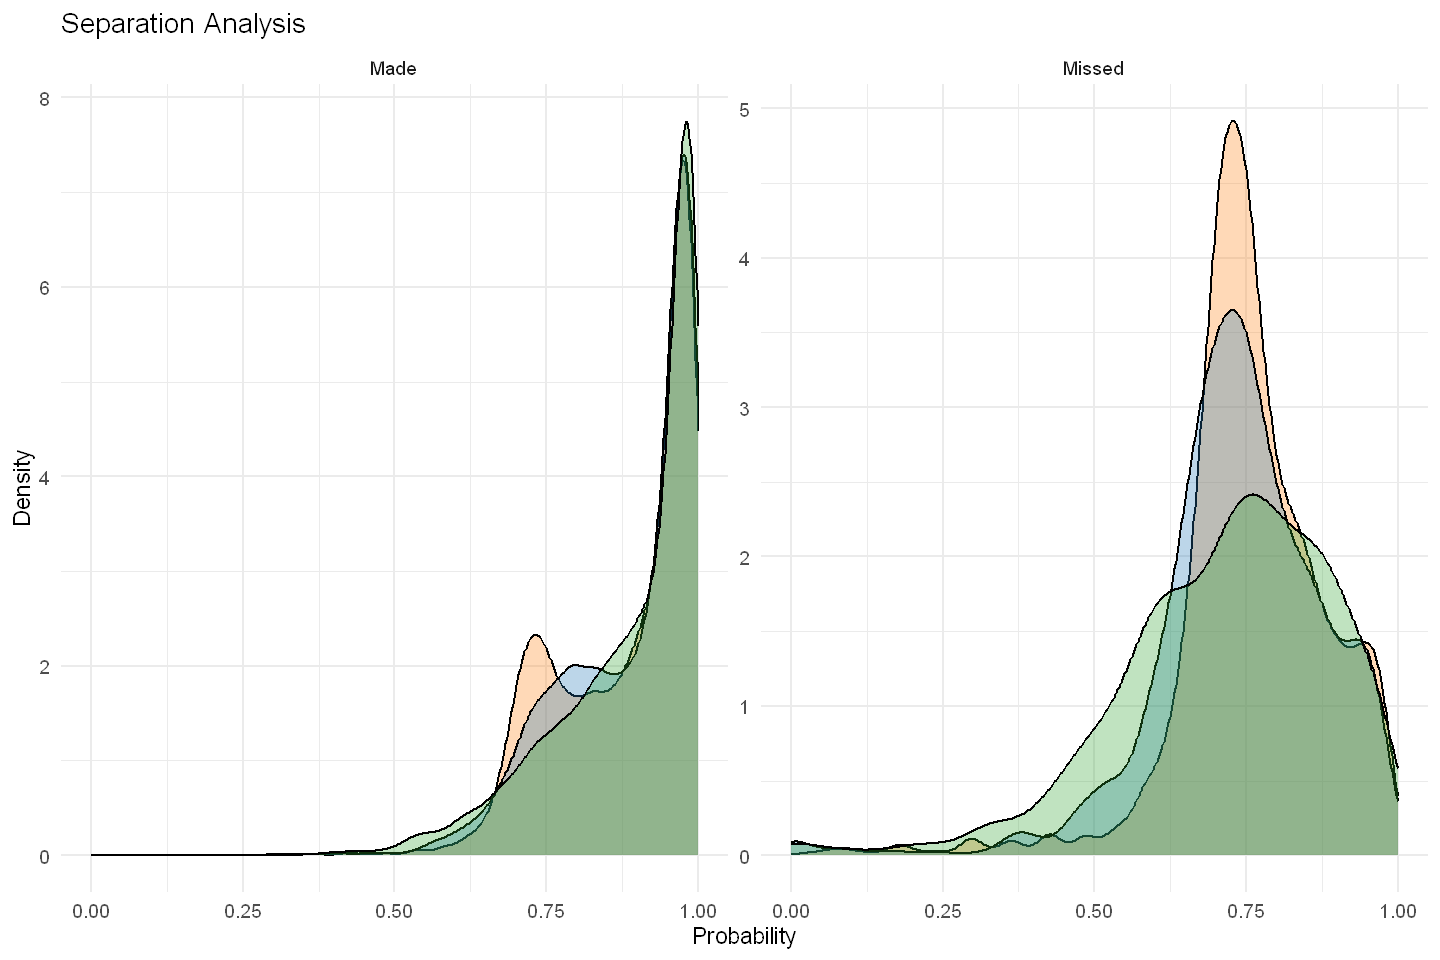

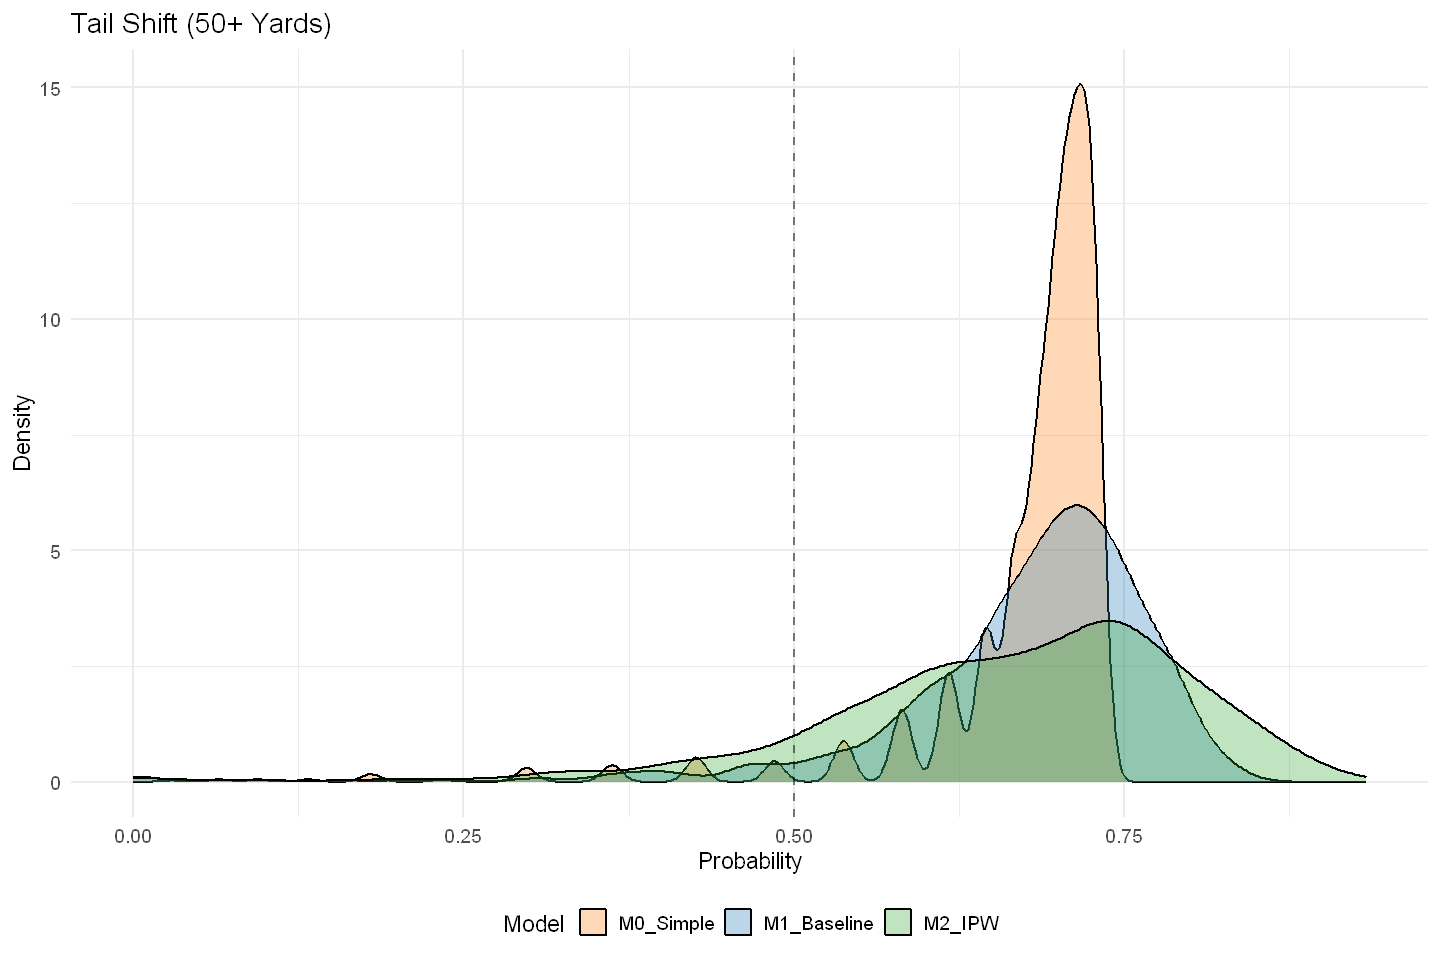

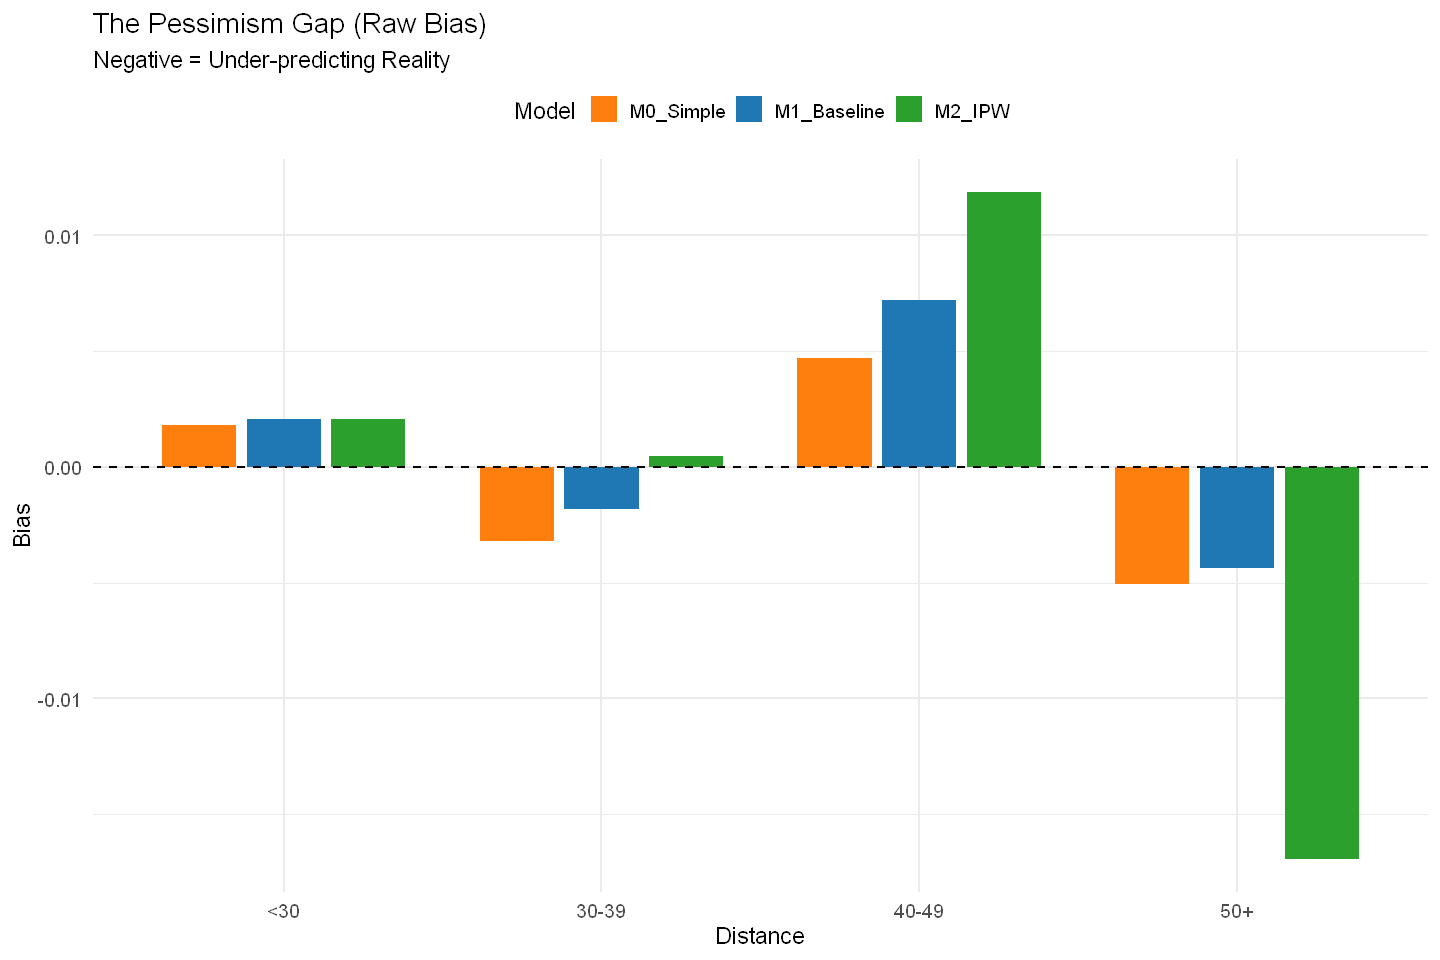

In [44]:
# ==============================================================================
# 1. Setup & Data Prep
# ==============================================================================

# Define Palette (M0 = Orange, M1 = Blue, M2 = Green)
cols <- c("M0_Simple"   = "#ff7f0e", # Orange
          "M1_Baseline" = "#1f77b4", # Blue
          "M2_IPW"      = "#2ca02c") # Green

# A. Construct Comparison Dataframe
# Uses vectors p_m0_full, p_m1_full, p_m2_full created in the previous eval step
comparison_df <- fg_full_pooled %>%
  dplyr::select(kick_made, kick_distance) %>%
  dplyr::mutate(
    M0_Simple   = p_m0_full,
    M1_Baseline = p_m1_full,
    M2_IPW      = p_m2_full,
    
    # Create bins for summary stats
    dist_bin = dplyr::case_when(
      kick_distance < 30 ~ "<30",
      kick_distance < 40 ~ "30-39",
      kick_distance < 50 ~ "40-49",
      kick_distance >= 50 ~ "50+"
    )
  )

# Force Factor Order
comparison_df$dist_bin <- factor(comparison_df$dist_bin, levels = c("<30", "30-39", "40-49", "50+"))

# B. Calculate Detailed Metrics (Summary Table)
detailed_metrics <- comparison_df %>%
  dplyr::group_by(dist_bin) %>%
  dplyr::summarise(
    n = dplyr::n(),
    
    # Raw Bias (Signed) for Pessimism Gap
    bias_m0 = mean(M0_Simple) - mean(kick_made),
    bias_m1 = mean(M1_Baseline) - mean(kick_made),
    bias_m2 = mean(M2_IPW) - mean(kick_made),
    
    # Calibration Error (Absolute)
    calib_m0 = abs(mean(M0_Simple) - mean(kick_made)),
    calib_m1 = abs(mean(M1_Baseline) - mean(kick_made)),
    calib_m2 = abs(mean(M2_IPW) - mean(kick_made)),
    
    .groups = "drop"
  )

# C. Prepare Binned Truth Data (5-yard buckets)
truth_binned <- comparison_df %>%
  mutate(bin_start = floor(kick_distance / 5) * 5) %>%
  group_by(bin_start) %>%
  summarise(
    n = n(), 
    obs_prob = mean(kick_made),
    se = sqrt((obs_prob * (1 - obs_prob)) / n), 
    .groups = "drop"
  ) %>%
  filter(n > 10)

# D. Prepare Long-Format Data for Plotting
plot_curve_data <- comparison_df %>%
  select(kick_distance, kick_made, M0_Simple, M1_Baseline, M2_IPW) %>%
  pivot_longer(cols = c(M0_Simple, M1_Baseline, M2_IPW), 
               names_to = "Model", values_to = "Prob")

dist_plot_data <- comparison_df %>%
  select(kick_made, kick_distance, M0_Simple, M1_Baseline, M2_IPW, dist_bin) %>%
  pivot_longer(cols = c(M0_Simple, M1_Baseline, M2_IPW), 
               names_to = "Model", values_to = "Probability") %>%
  mutate(Outcome = ifelse(kick_made == 1, "Made", "Missed"))

# ==============================================================================
# 2. Plot Generation
# ==============================================================================

# --- Plot 1: The Truth Curve ---
p_truth <- ggplot() +
  # Models (Smooth Lines)
  geom_smooth(data = plot_curve_data, 
              aes(x = kick_distance, y = Prob, color = Model, linetype = Model), 
              method = "loess", span = 0.5, size = 1.2, se = FALSE) +
  # Truth (Points + Error Bars)
  geom_point(data = truth_binned, aes(x = bin_start + 2.5, y = obs_prob), size = 3) +
  geom_errorbar(data = truth_binned, aes(x = bin_start + 2.5, ymin = obs_prob - se, ymax = obs_prob + se), width = 2) +
  # Styling
  scale_color_manual(values = cols) +
  scale_linetype_manual(values = c("dotted", "dashed", "solid")) +
  labs(title = "Truth Curve: Predicted vs Actual", x = "Kick Distance", y = "Probability") +
  theme_minimal(base_size = 14) + theme(legend.position = "top")

# --- Plot 2: The Bias Curve ---
p_bias <- ggplot(plot_curve_data %>% mutate(Residual = Prob - kick_made), 
                 aes(x = kick_distance, y = Residual, color = Model)) +
  geom_hline(yintercept = 0, color = "black", size = 1) +
  geom_smooth(method = "loess", span = 0.5, se = TRUE, alpha = 0.15, size = 1.2) +
  scale_color_manual(values = cols) +
  labs(title = "Bias Curve: Residual Analysis", x = "Kick Distance", y = "Bias (Pred - Obs)") +
  theme_minimal(base_size = 14) + theme(legend.position = "top")

# --- Plot 3: Global Density ---
p_dens_global <- ggplot(dist_plot_data, aes(x = Probability, fill = Model)) +
  geom_density(alpha = 0.3) +
  scale_fill_manual(values = cols) +
  labs(title = "Global Probability Density", x = "Probability", y = "Density") +
  theme_minimal(base_size = 14) + theme(legend.position = "none")

# --- Plot 4: Separation Analysis ---
p_dens_sep <- ggplot(dist_plot_data, aes(x = Probability, fill = Model)) +
  geom_density(alpha = 0.3) +
  facet_wrap(~Outcome, scales = "free_y") +
  scale_fill_manual(values = cols) +
  labs(title = "Separation Analysis", x = "Probability", y = "Density") +
  theme_minimal(base_size = 14) + theme(legend.position = "none")

# --- Plot 5: Tail Shift (50+ Yards) ---
p_dens_tail <- ggplot(dist_plot_data %>% filter(dist_bin == "50+"), aes(x = Probability, fill = Model)) +
  geom_density(alpha = 0.3) +
  scale_fill_manual(values = cols) +
  geom_vline(xintercept = 0.5, linetype="dashed", alpha=0.5) +
  labs(title = "Tail Shift (50+ Yards)", x = "Probability", y = "Density") +
  theme_minimal(base_size = 14) + theme(legend.position = "bottom")

# --- Plot 6: Pessimism Gap (Bar Chart) ---
bias_bar_data <- detailed_metrics %>%
  select(dist_bin, starts_with("bias")) %>%
  pivot_longer(cols = -dist_bin, names_to = c("Metric", "Model"), names_sep = "_") %>%
  mutate(Model = case_when(Model == "m0" ~ "M0_Simple", Model == "m1" ~ "M1_Baseline", Model == "m2" ~ "M2_IPW"))

p_bar_bias <- ggplot(bias_bar_data, aes(x = dist_bin, y = value, fill = Model)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.8), width = 0.7) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "black") +
  scale_fill_manual(values = cols) +
  labs(title = "The Pessimism Gap (Raw Bias)", subtitle = "Negative = Under-predicting Reality", x = "Distance", y = "Bias") +
  theme_minimal(base_size = 14) + theme(legend.position = "top")

# ==============================================================================
# 3. Display
# ==============================================================================

options(repr.plot.width = 12, repr.plot.height = 8)
print(p_truth)
print(p_bias)
print(p_dens_global)
print(p_dens_sep)
print(p_dens_tail)
print(p_bar_bias)


--- Metrics Separated by Outcome ---
# A tibble: 6 × 7
  Model       Outcome_Label     n Mean_Prob  Brier LogLoss Calib_Error
  <chr>       <chr>         <int>     <dbl>  <dbl>   <dbl>       <dbl>
1 M0_Simple   Make (y=1)     8986     0.878 0.0271   0.139       0.122
2 M0_Simple   Miss (y=0)     1446     0.757 0.589    1.59        0.757
3 M1_Baseline Make (y=1)     8986     0.883 0.0260   0.134       0.117
4 M1_Baseline Miss (y=0)     1446     0.737 0.564    1.52        0.737
5 M2_IPW      Make (y=1)     8986     0.886 0.0269   0.131       0.114
6 M2_IPW      Miss (y=0)     1446     0.717 0.544    1.50        0.717


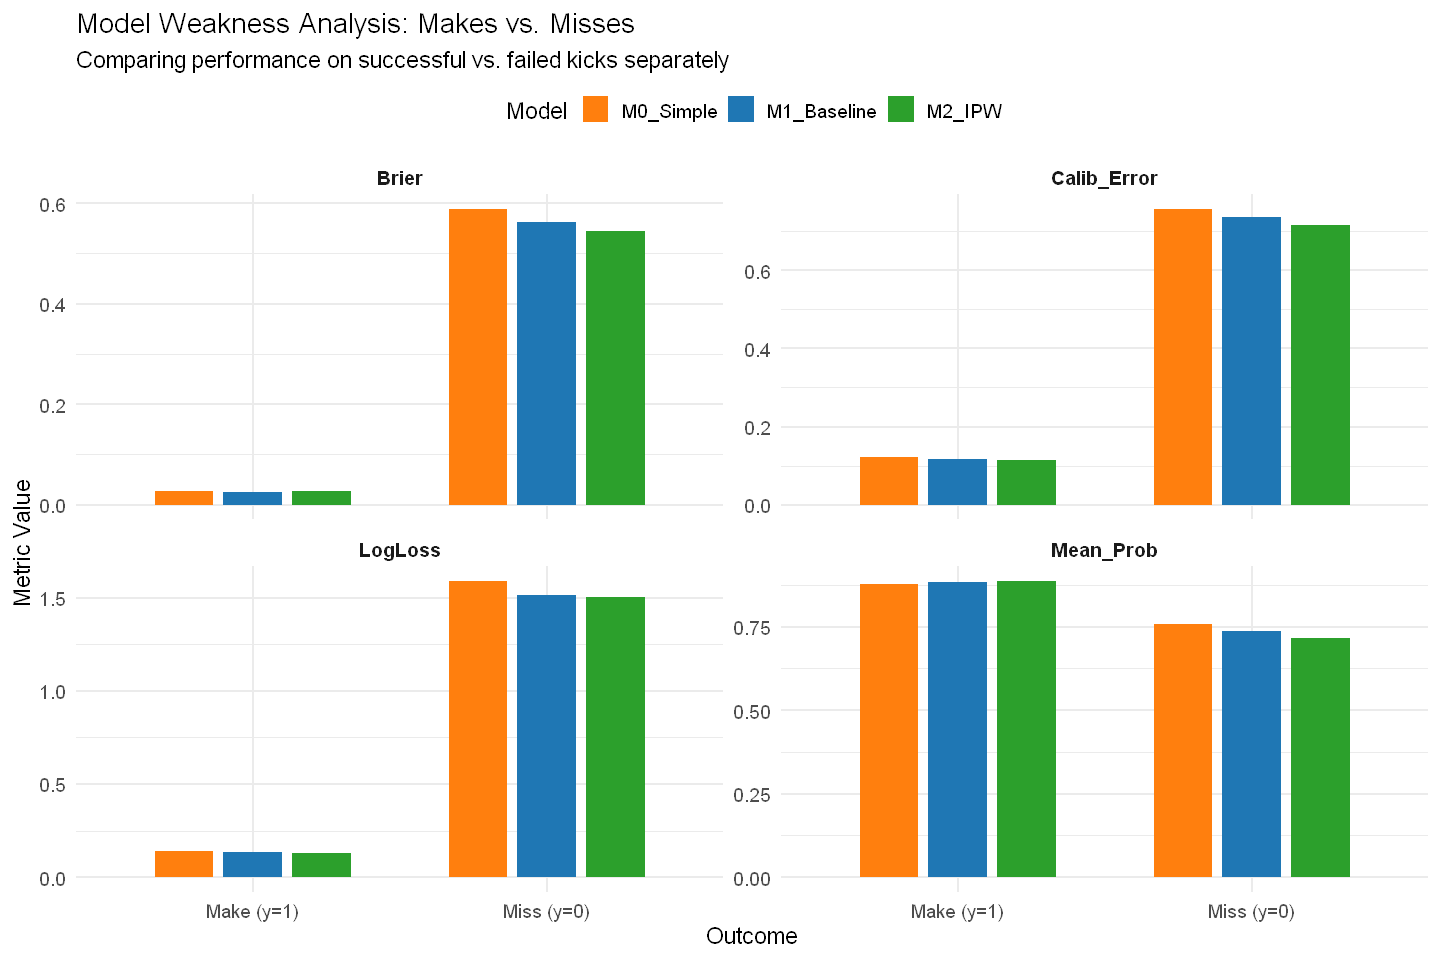

In [45]:
# ==============================================================================
# 1. Calculate Metrics by Outcome
# ==============================================================================

# Reshape data to Long format for processing
# Assumes 'comparison_df' exists from the previous M0/M1/M2 analysis
outcome_analysis <- comparison_df %>%
  dplyr::select(kick_made, M0_Simple, M1_Baseline, M2_IPW) %>%
  tidyr::pivot_longer(
    cols = c(M0_Simple, M1_Baseline, M2_IPW),
    names_to = "Model", 
    values_to = "Prob"
  ) %>%
  dplyr::mutate(Outcome_Label = ifelse(kick_made == 1, "Make (y=1)", "Miss (y=0)")) %>%
  dplyr::group_by(Model, Outcome_Label) %>%
  dplyr::summarise(
    n = dplyr::n(),
    
    # Average Predicted Probability (Confidence)
    Mean_Prob = mean(Prob),
    
    # Brier Score (Prediction Error)
    # For Makes: (1 - p)^2
    # For Misses: (0 - p)^2
    Brier = mean((kick_made - Prob)^2),
    
    # Log Loss (Information Loss)
    # Using pmax to avoid log(0)
    LogLoss = -mean(ifelse(kick_made == 1, 
                           log(pmax(Prob, 1e-15)), 
                           log(pmax(1 - Prob, 1e-15)))),
    
    # Calibration Error (Bias)
    # For Makes: |Mean_Prob - 1|
    # For Misses: |Mean_Prob - 0|
    Calib_Error = abs(mean(Prob) - mean(kick_made)),
    
    .groups = "drop"
  )

cat("\n--- Metrics Separated by Outcome ---\n")
print(outcome_analysis)

# ==============================================================================
# 2. Visualization
# ==============================================================================

# Define Colors
cols <- c("M0_Simple" = "#ff7f0e", "M1_Baseline" = "#1f77b4", "M2_IPW" = "#2ca02c")

# Reshape for Faceted Plotting
plot_outcome <- outcome_analysis %>%
  tidyr::pivot_longer(cols = c(Brier, LogLoss, Calib_Error, Mean_Prob), 
                      names_to = "Metric", values_to = "Value")

# Plot
p_outcome <- ggplot(plot_outcome, aes(x = Outcome_Label, y = Value, fill = Model)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.7), width = 0.6) +
  facet_wrap(~Metric, scales = "free_y") +
  scale_fill_manual(values = cols) +
  labs(
    title = "Model Weakness Analysis: Makes vs. Misses",
    subtitle = "Comparing performance on successful vs. failed kicks separately",
    x = "Outcome",
    y = "Metric Value"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "top",
    strip.text = element_text(face = "bold")
  )

print(p_outcome)


--- Top 10 Kickers by Skill (FGOE per Kick) ---
# A tibble: 10 × 10
   kicker_player_name Seasons Attempts Actual_Makes Exp_Makes_M0 FGOE_Total
   <chr>                <int>    <int>        <int>        <dbl>      <dbl>
 1 B.Aubrey                 2       83           77         67.1       9.90
 2 C.Dicker                 3      102           96         87.9       8.07
 3 J.Tucker                10      368          332        312.       20.4 
 4 C.Boswell               10      321          289        277.       12.5 
 5 G.Gano                   9      249          221        212.        9.24
 6 M.Bryant                 5      134          119        114.        4.72
 7 C.McLaughlin             6      150          132        127.        5.24
 8 N.Folk                   9      230          207        200.        6.86
 9 R.Gould                  8      251          227        220.        7.40
10 J.Sanders                7      218          190        185.        5.31
   FGOE_Per_Kick Av

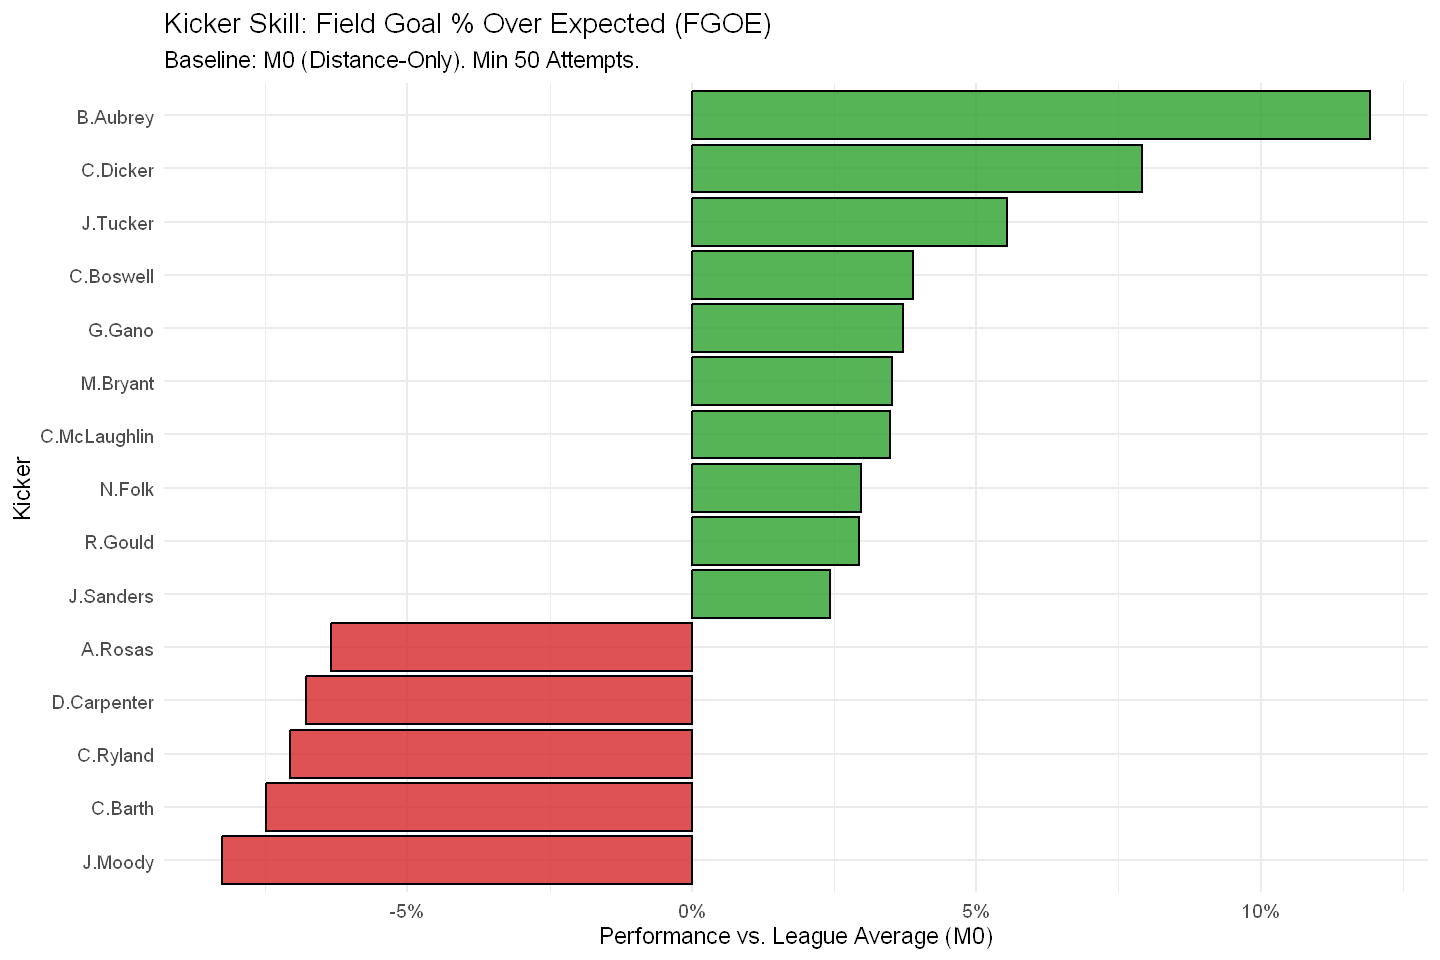

`geom_smooth()` using formula = 'y ~ x'


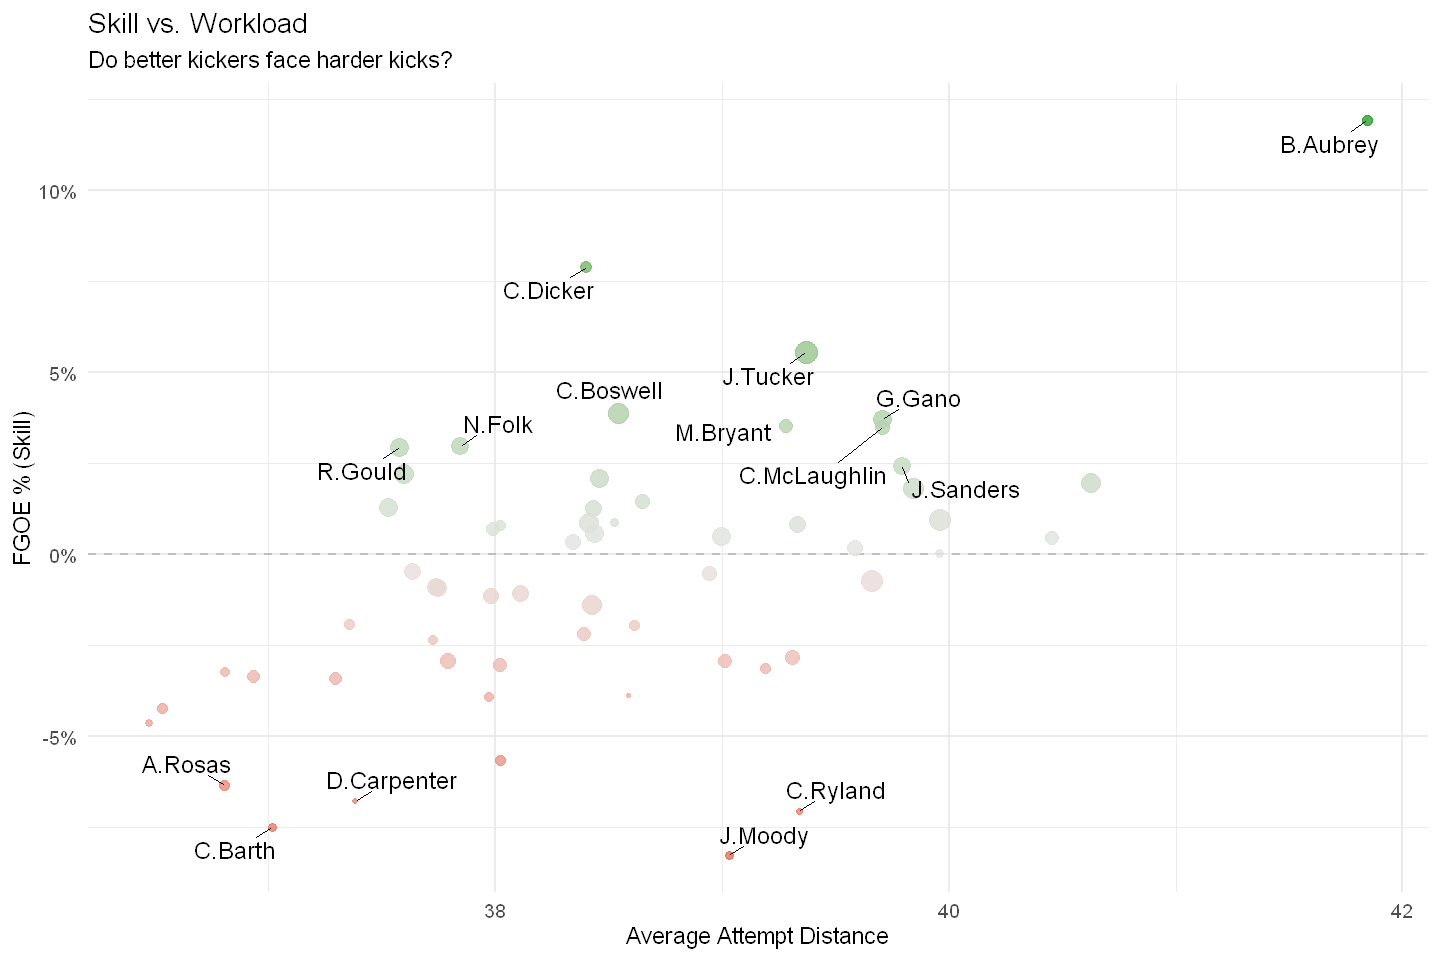

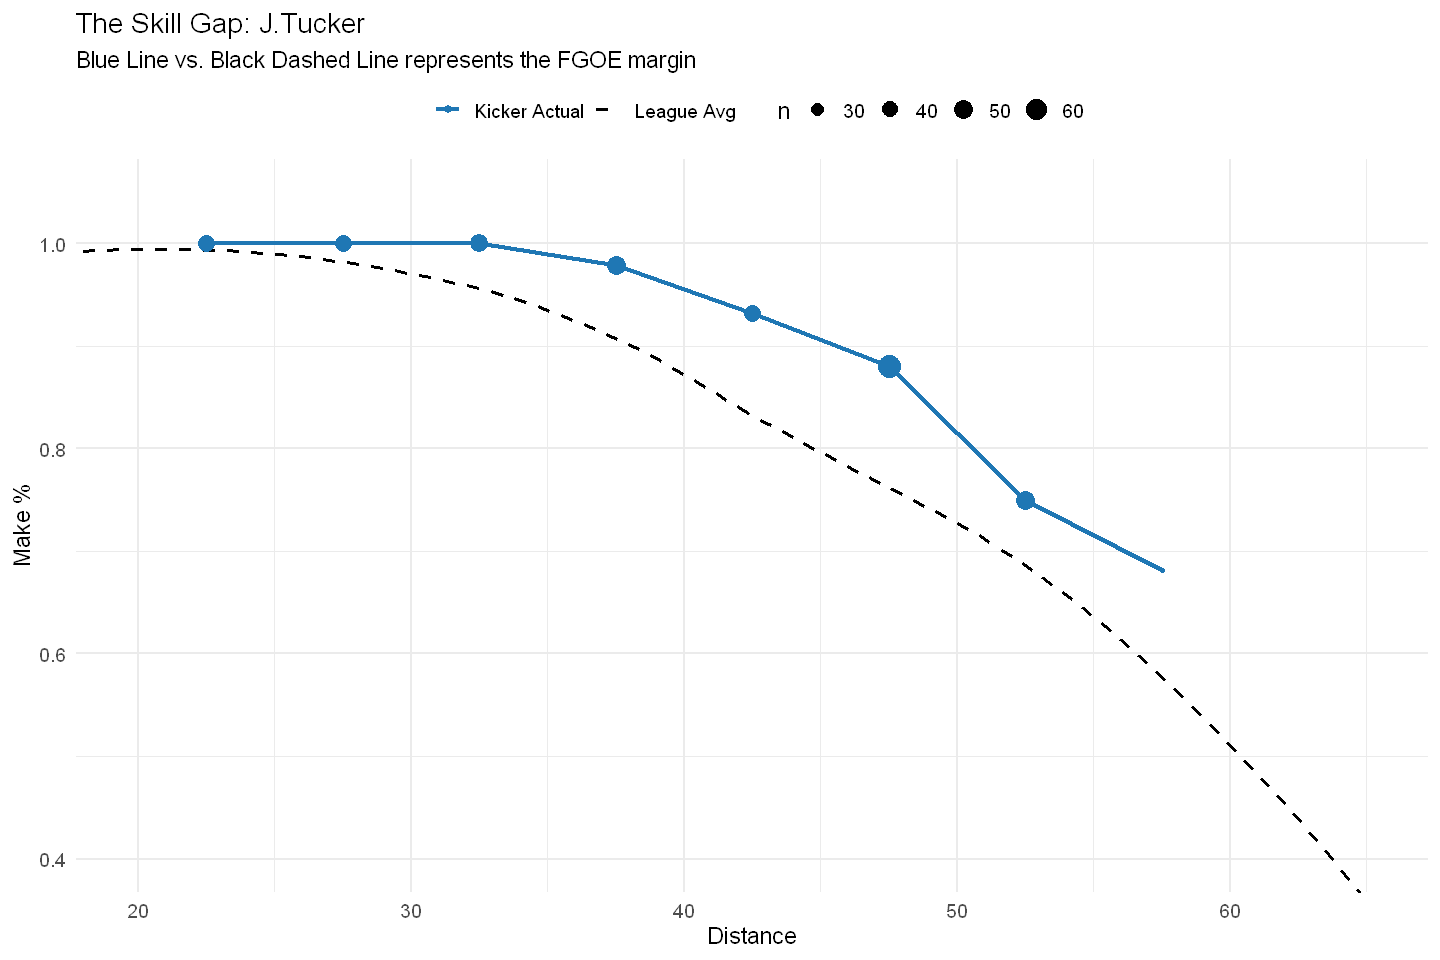

In [33]:
# ==============================================================================
# 1. Data Prep: Bind Predictions & Calculate FGOE
# ==============================================================================

# CRITICAL STEP: Add the prediction vector 'p_m0_full' to the dataframe as a column
# This ensures group_by() slices the predictions correctly for each kicker.
fg_skill_data <- fg_full_pooled %>%
  dplyr::mutate(
    # Ensure we use the vector from the environment if it exists, 
    # otherwise check if column already exists.
    p_m0 = if(exists("p_m0_full")) p_m0_full else pred_m0_full
  )

# Calculate Skill Metrics
kicker_skill <- fg_skill_data %>%
  dplyr::group_by(kicker_player_name) %>%
  dplyr::summarise(
    Seasons = n_distinct(season),
    Attempts = n(),
    
    # Metric Components
    Actual_Makes = sum(kick_made),
    Exp_Makes_M0 = sum(p_m0), # Summing the column (Distance Expectation)
    
    # The Metric: FGOE
    FGOE_Total = Actual_Makes - Exp_Makes_M0,
    FGOE_Per_Kick = FGOE_Total / Attempts,
    
    # Context
    Avg_Distance = mean(kick_distance),
    Actual_Pct = mean(kick_made),
    Exp_Pct = mean(p_m0),
    
    .groups = "drop"
  ) %>%
  # Filter for sample size (min 50 attempts) to remove noise
  dplyr::filter(Attempts >= 50) %>%
  dplyr::arrange(desc(FGOE_Per_Kick))

cat("\n--- Top 10 Kickers by Skill (FGOE per Kick) ---\n")
# Sets the option to always print all columns for tibbles
options(tibble.width = Inf)
print(head(kicker_skill, 10))

# ==============================================================================
# 2. Visual 1: The Skill Leaderboard (Bar Chart)
# ==============================================================================

# Select Top 10 and Bottom 5 for the chart
top_kickers <- head(kicker_skill, 10)
bottom_kickers <- tail(kicker_skill, 5)
plot_leaderboard <- bind_rows(top_kickers, bottom_kickers) %>%
  mutate(
    Color = ifelse(FGOE_Per_Kick > 0, "#2ca02c", "#d62728"), # Green/Red
    Label = paste0(kicker_player_name, " (", round(FGOE_Per_Kick*100, 1), "%)")
  )

p_rank <- ggplot(plot_leaderboard, aes(x = reorder(kicker_player_name, FGOE_Per_Kick), y = FGOE_Per_Kick, fill = Color)) +
  geom_bar(stat = "identity", color = "black", alpha = 0.8) +
  coord_flip() +
  scale_fill_identity() +
  scale_y_continuous(labels = scales::percent) +
  labs(
    title = "Kicker Skill: Field Goal % Over Expected (FGOE)",
    subtitle = "Baseline: M0 (Distance-Only). Min 50 Attempts.",
    x = "Kicker",
    y = "Performance vs. League Average (M0)"
  ) +
  theme_minimal(base_size = 14)

# ==============================================================================
# 3. Visual 2: Skill vs. Difficulty (Scatter)
# ==============================================================================

p_scatter <- ggplot(kicker_skill, aes(x = Avg_Distance, y = FGOE_Per_Kick)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey") +
  geom_point(aes(size = Attempts, color = FGOE_Per_Kick), alpha = 0.8) +
  # Label the top performers automatically
  ggrepel::geom_text_repel(
    data = plot_leaderboard, 
    aes(label = kicker_player_name), 
    size = 5, box.padding = 0.5
  ) +
  scale_color_gradient2(low = "#d62728", mid = "grey90", high = "#2ca02c", midpoint = 0) +
  scale_y_continuous(labels = scales::percent) +
  labs(
    title = "Skill vs. Workload",
    subtitle = "Do better kickers face harder kicks?",
    x = "Average Attempt Distance",
    y = "FGOE % (Skill)"
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "none")

# ==============================================================================
# 4. Visual 3: The "GOAT" Curve (Visualizing Skill)
# ==============================================================================

# Identify the #1 Kicker
goat_id <- kicker_skill %>% arrange(desc(FGOE_Total)) %>% slice(1) %>% pull(kicker_player_name)

# Get GOAT's Data (Binned for plotting points)
goat_data <- fg_skill_data %>% 
  filter(kicker_player_name == goat_id) %>%
  mutate(bin = floor(kick_distance/5)*5) %>%
  group_by(bin) %>%
  summarise(
    n = n(),
    obs_rate = mean(kick_made), 
    exp_rate = mean(p_m0)
  ) %>%
  filter(n >= 5)

# Get League Average Curve Data
# We select the columns explicitly to avoid the previous error
league_curve <- fg_skill_data %>%
  dplyr::select(kick_distance, p_m0) %>%
  dplyr::rename(Prob = p_m0)

p_curve <- ggplot() +
  # A. League Average Line (M0)
  geom_smooth(data = league_curve, aes(x = kick_distance, y = Prob, color = "League Avg"), 
              method = "loess", linetype = "dashed", size = 1, se = FALSE) +
  # B. The Kicker's Performance
  geom_line(data = goat_data, aes(x = bin + 2.5, y = obs_rate, color = "Kicker Actual"), size = 1.2) +
  geom_point(data = goat_data, aes(x = bin + 2.5, y = obs_rate, size = n, color = "Kicker Actual")) +
  # Colors
  scale_color_manual(values = c("League Avg" = "black", "Kicker Actual" = "#1f77b4")) +
  coord_cartesian(ylim = c(0.4, 1.05), xlim = c(20, 65)) +
  labs(
    title = paste0("The Skill Gap: ", goat_id),
    subtitle = "Blue Line vs. Black Dashed Line represents the FGOE margin",
    x = "Distance", y = "Make %", color = ""
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "top")

# ==============================================================================
# 5. Display Plots
# ==============================================================================

options(repr.plot.width = 12, repr.plot.height = 8)
print(p_rank)
print(p_scatter)
print(p_curve)


--- Top 10 Kickers by Difficulty of Workload (Lowest Mean Propensity) ---
These kickers attempt the shots that most coaches decline.
# A tibble: 10 × 5
   kicker_player_name n_attempts mean_attempt_prob avg_distance avg_weight
   <chr>                   <int>             <dbl>        <dbl>      <dbl>
 1 B.Aubrey                   83             0.746         41.8      1.41 
 2 W.Reichard                 31             0.753         41.7      1.21 
 3 J.Bates                    30             0.768         41.2      1.21 
 4 J.Slye                    175             0.768         39.6      1.15 
 5 M.Wright                   63             0.781         38.5      1.16 
 6 B.Maher                   143             0.793         39.3      1.18 
 7 E.McPherson               134             0.797         40.5      0.962
 8 M.Prater                  289             0.798         40.6      1.12 
 9 M.Gay                     205             0.799         39.3      1.000
10 G.Zuerlein         

# A tibble: 5 × 5
  kicker_player_name n_attempts mean_attempt_prob avg_distance avg_weight
  <chr>                   <int>             <dbl>        <dbl>      <dbl>
1 M.Nugent                   90             0.875         36.5      0.815
2 S.Gostkowski              196             0.875         37.6      0.847
3 B.Walsh                    86             0.886         38.0      0.807
4 T.Coons                    36             0.920         32.6      0.741
5 R.Aguayo                   30             0.925         36.3      0.732


`geom_smooth()` using formula = 'y ~ x'


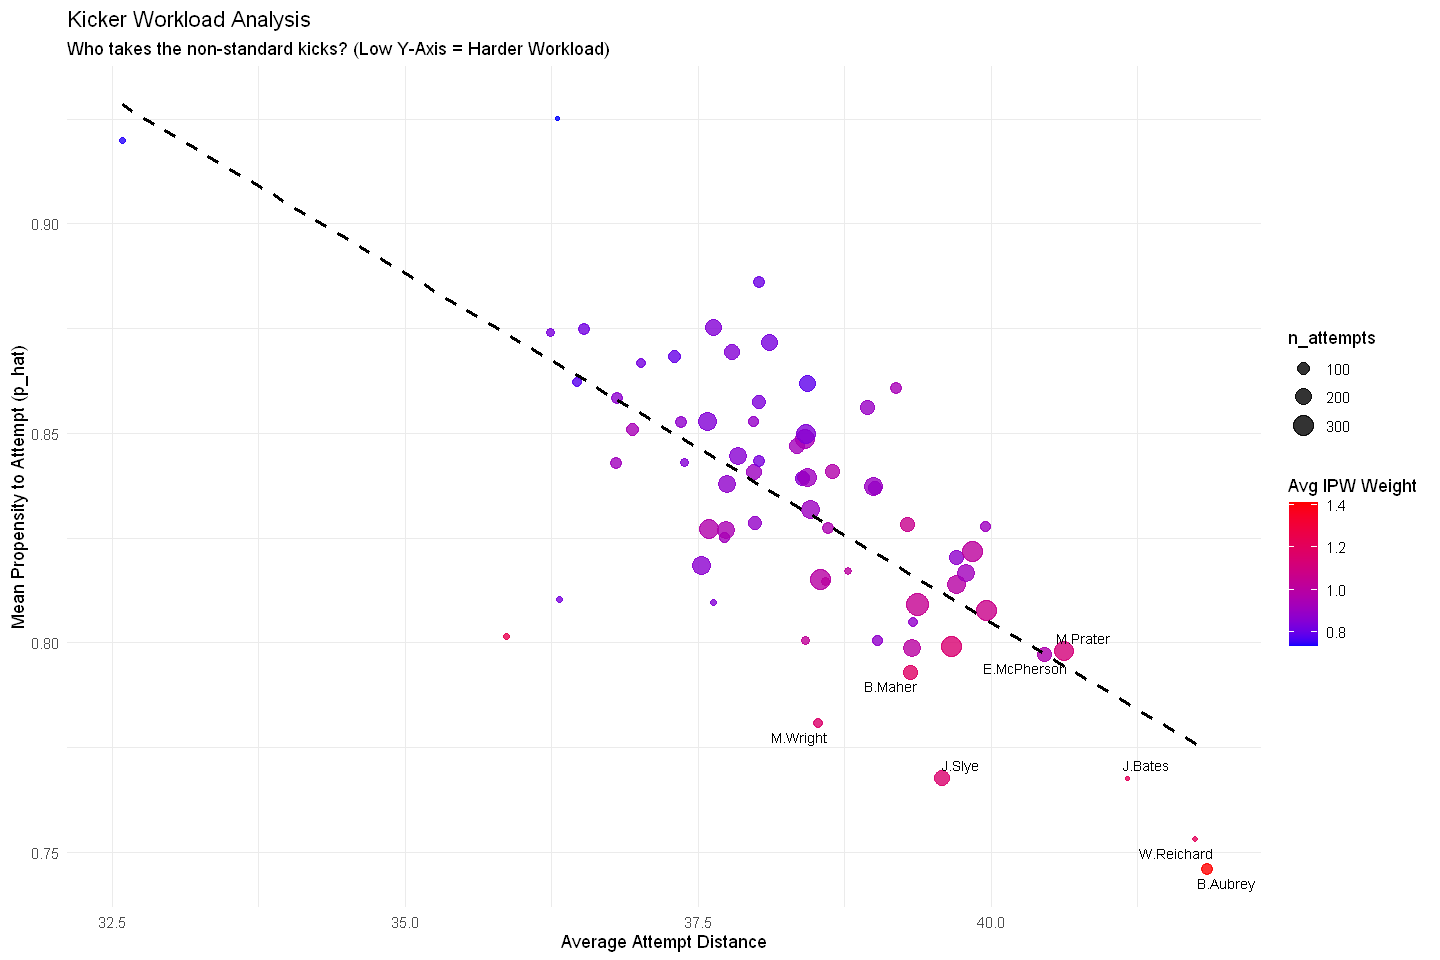

In [46]:
library(tidyverse)

# 1. Calculate Mean Propensity per Kicker
# We use 'p_hat_multinom' which is the probability of the attempt occurring
kicker_propensity <- fg_full_pooled %>%
  dplyr::group_by(kicker_player_name) %>%
  dplyr::summarise(
    n_attempts = dplyr::n(),
    
    # The metric: How "standard" are their attempts?
    mean_attempt_prob = mean(p_hat_multinom, na.rm = TRUE),
    
    # Context: What does their workload look like?
    avg_distance = mean(kick_distance, na.rm = TRUE),
    avg_weight = mean(as.numeric(weight_multinom_hajek), na.rm = TRUE),
    
    .groups = "drop"
  ) %>%
  # Filter for sample size to remove noise (e.g., injury replacements)
  dplyr::filter(n_attempts >= 30) %>%
  dplyr::arrange(mean_attempt_prob) # Rank Low to High

# 2. Display the "Risk Takers" (Lowest Propensity)
cat("\n--- Top 10 Kickers by Difficulty of Workload (Lowest Mean Propensity) ---\n")
cat("These kickers attempt the shots that most coaches decline.\n")
print(head(kicker_propensity, 10))

# 3. Display the "Safe" Kickers (Highest Propensity)
cat("\n--- Top 5 Kickers with 'Safe' Workloads (Highest Mean Propensity) ---\n")
print(tail(kicker_propensity, 5))

# 4. Visual: Propensity vs. Distance
# This confirms that 'Low Propensity' is a proxy for 'Long Distance'
p_prop <- ggplot(kicker_propensity, aes(x = avg_distance, y = mean_attempt_prob)) +
  geom_point(aes(size = n_attempts, color = avg_weight), alpha = 0.8) +
  geom_smooth(method = "lm", color = "black", linetype = "dashed", se = FALSE) +
  ggrepel::geom_text_repel(data = head(kicker_propensity, 8), aes(label = kicker_player_name), size = 3) +
  scale_color_gradient(low = "blue", high = "red", name = "Avg IPW Weight") +
  labs(
    title = "Kicker Workload Analysis",
    subtitle = "Who takes the non-standard kicks? (Low Y-Axis = Harder Workload)",
    x = "Average Attempt Distance",
    y = "Mean Propensity to Attempt (p_hat)"
  ) +
  theme_minimal()

print(p_prop)

In [ ]:
# ==============================================================================
# 1. Robust Formula Construction (Manual Build)
# ==============================================================================

# Load the base model to get terms
m1_model_path <- file.path(models_dir, "m1", "m1_fg_B_logit.rds")
if (!file.exists(m1_model_path)) stop("M1 model not found.")
m1_saved_model <- readRDS(m1_model_path)

# Extract all terms as a character vector
# We use labels() to get the fixed effects strings
all_terms <- labels(terms(m1_saved_model))

# Identify terms to EXCLUDE
# 1. Kicker-Specific terms (Age, Experience, Interactions)
# 2. Existing Random Effects (Anything with "|") to prevent "1 | id" errors
terms_to_drop <- c(
  "high_altitude",
  "indoors",
  "kicker_age_z:kicker_experience_z",
  "kicker_player_id",
  "kicker_age",
  "kicker_experience",
  "|" # Drops all existing REs so we can add them back cleanly
)

# Filter the terms list
agnostic_terms <- all_terms
for (drop in terms_to_drop) {
  agnostic_terms <- agnostic_terms[!grepl(drop, agnostic_terms, fixed = TRUE)]
}

# Rebuild the Formula String manually
# 1. Fixed Effects (Splines, Weather, Context)
fixed_effects_str <- paste(agnostic_terms, collapse = " + ")

# 2. Add Agnostic Random Effects (Explicitly with Parentheses)
# We add Stadium (Location) and Season (Era)
agnostic_re_str <- "(1 | stadium_id) + (1 | season)"

# 3. Combine
final_formula_str <- paste("kick_made ~", fixed_effects_str, "+", agnostic_re_str)
m1_agnostic_formula <- as.formula(final_formula_str)

cat("\n--- Corrected M1 Agnostic Formula ---\n")
print(m1_agnostic_formula)

# ==============================================================================
# 2. Fit M1 Agnostic
# ==============================================================================

# Ensure 'season' is a factor for the Random Effect
fg_full_pooled$season <- as.factor(fg_full_pooled$season)

fit_m1_agnostic <- glmmTMB(
  formula = m1_agnostic_formula,
  data = fg_full_pooled,
  family = binomial(link = "logit"),
  control = ctrl
)

# ==============================================================================
# 3. Predict & Evaluate
# ==============================================================================

# Generate Predictions (The "Environment Adjusted Expectation")
cat("Generating predictions...\n")
fg_full_pooled$p_m1_agnostic <- predict_safe(fit_m1_agnostic, fg_full_pooled)

# Calculate Metrics
res_m1_agnostic <- calc_metrics(fg_full_pooled$kick_made, fg_full_pooled$p_m1_agnostic, set_name = "in_sample") %>%
  dplyr::mutate(Model = "M1_Agnostic (No Kicker ID)", .before = 1)

cat("\n--- M1 Agnostic In-Sample Metrics ---\n")
print(res_m1_agnostic)


--- Corrected M1 Agnostic Formula ---
kick_made ~ dist_bs_1 + dist_bs_2 + dist_bs_3 + dist_bs_4 + dist_bs_5 + 
    dist_bs_6 + dist_bs_7 + wind_z + temp_z + is_rain_showers + 
    is_snow_sleet + is_ot + iced + clock_running + posteam_timeouts_remaining + 
    wind_z:temp_z + clock_running:posteam_timeouts_remaining + 
    dist_bs_1:wind_z + dist_bs_2:wind_z + dist_bs_3:wind_z + 
    dist_bs_4:wind_z + dist_bs_5:wind_z + dist_bs_6:wind_z + 
    dist_bs_7:wind_z + dist_bs_1:temp_z + dist_bs_2:temp_z + 
    dist_bs_3:temp_z + dist_bs_4:temp_z + dist_bs_5:temp_z + 
    dist_bs_6:temp_z + dist_bs_7:temp_z + (1 | stadium_id) + 
    (1 | season)

Fitting M1 Agnostic (Environment + Season only)...
Generating predictions...

--- M1 Agnostic In-Sample Metrics ---
# A tibble: 1 × 10
  Model                      set       brier logloss   auc calib_error accuracy
  <chr>                      <chr>     <dbl>   <dbl> <dbl>       <dbl>    <dbl>
1 M1_Agnostic (No Kicker ID) in_sample 0.103   0.334 0.


--- Top 10 Kickers by True Skill (Environment Adjusted FGOE) ---
# A tibble: 10 × 10
   kicker_player_name Seasons Attempts Actual_Makes Exp_Makes_Agnostic
   <chr>                <int>    <int>        <int>              <dbl>
 1 B.Aubrey                 2       83           77               69.5
 2 C.Dicker                 3      102           96               89.8
 3 J.Tucker                10      368          332              313. 
 4 N.Folk                   9      230          207              199. 
 5 C.McLaughlin             6      150          132              127. 
 6 G.Gano                   9      249          221              213. 
 7 C.Boswell               10      321          289              278. 
 8 J.Sanders                7      218          190              183. 
 9 M.Bryant                 5      134          119              115. 
10 R.Gould                  8      251          227              220. 
   FGOE_Total FGOE_Per_Kick Avg_Distance Actual_Pct Exp_Pct_Ag

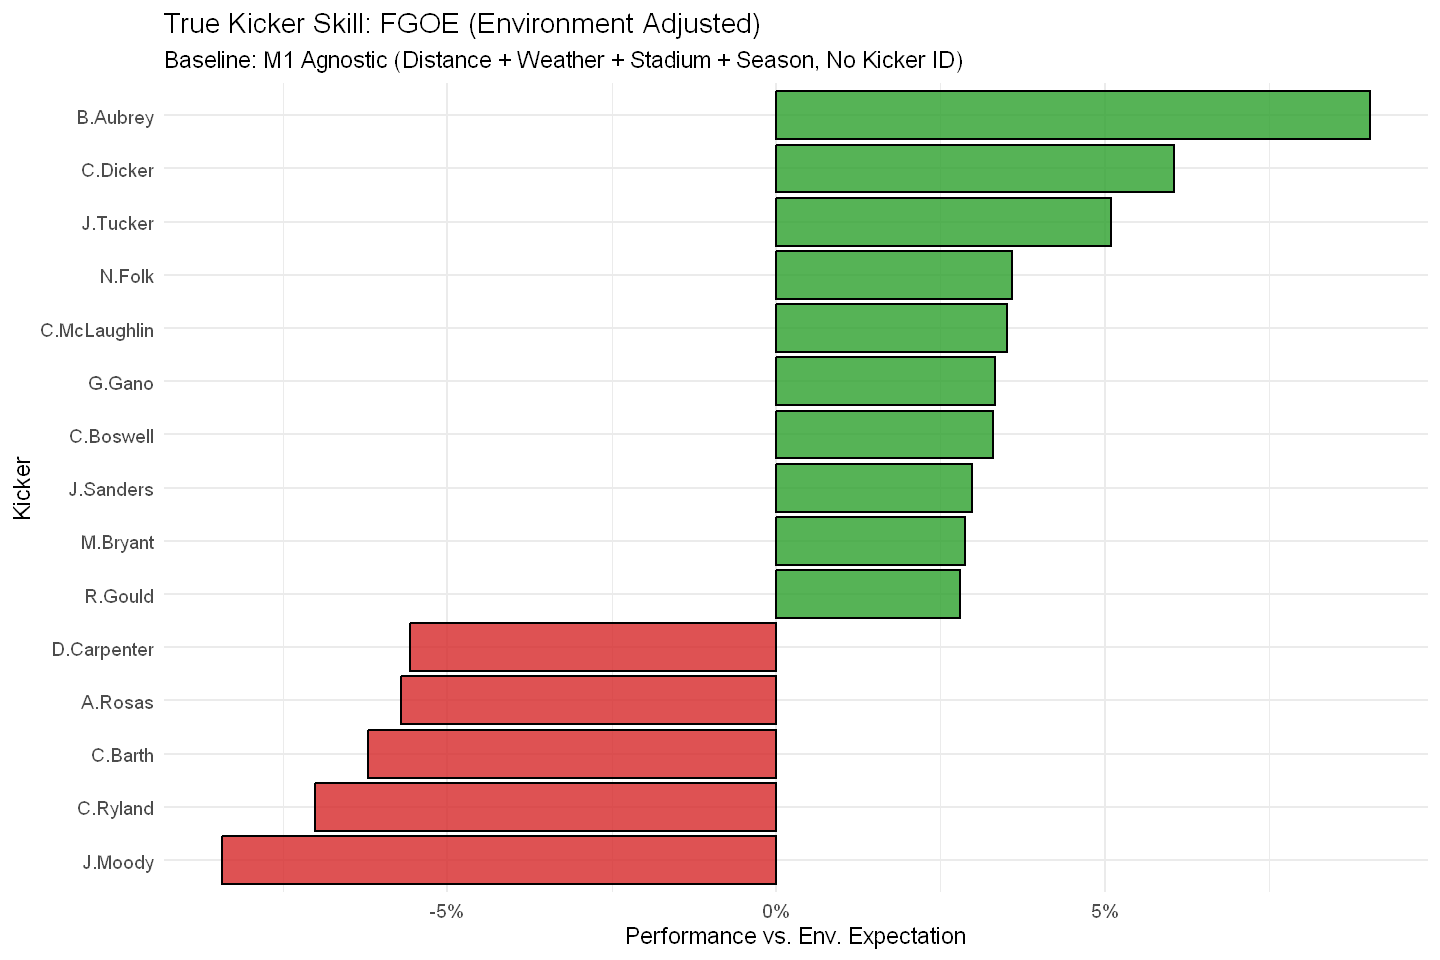

`geom_smooth()` using formula = 'y ~ x'


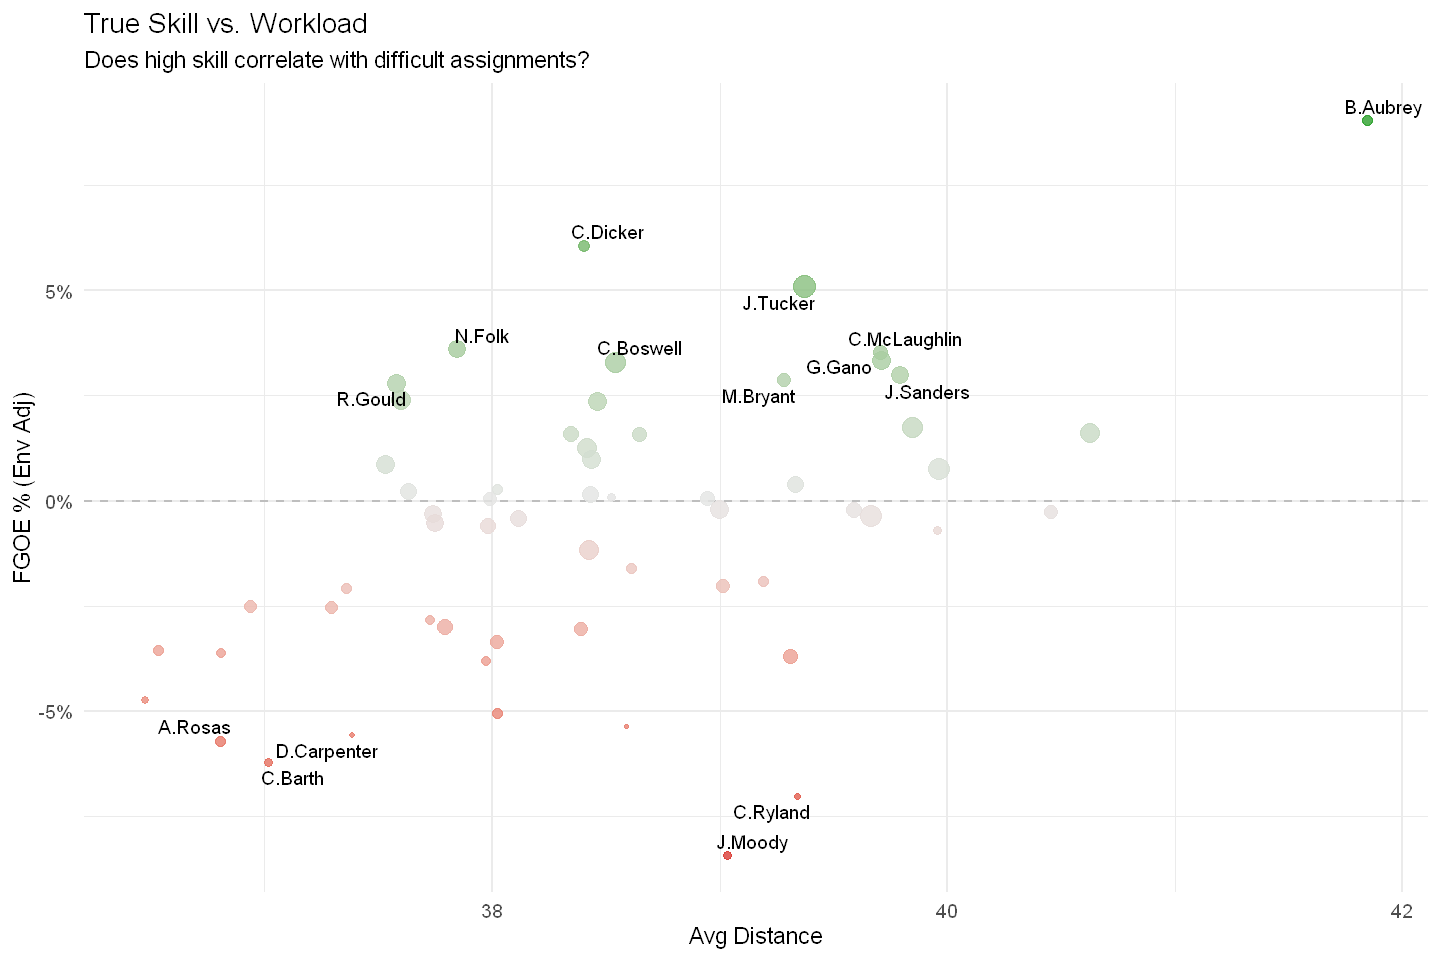

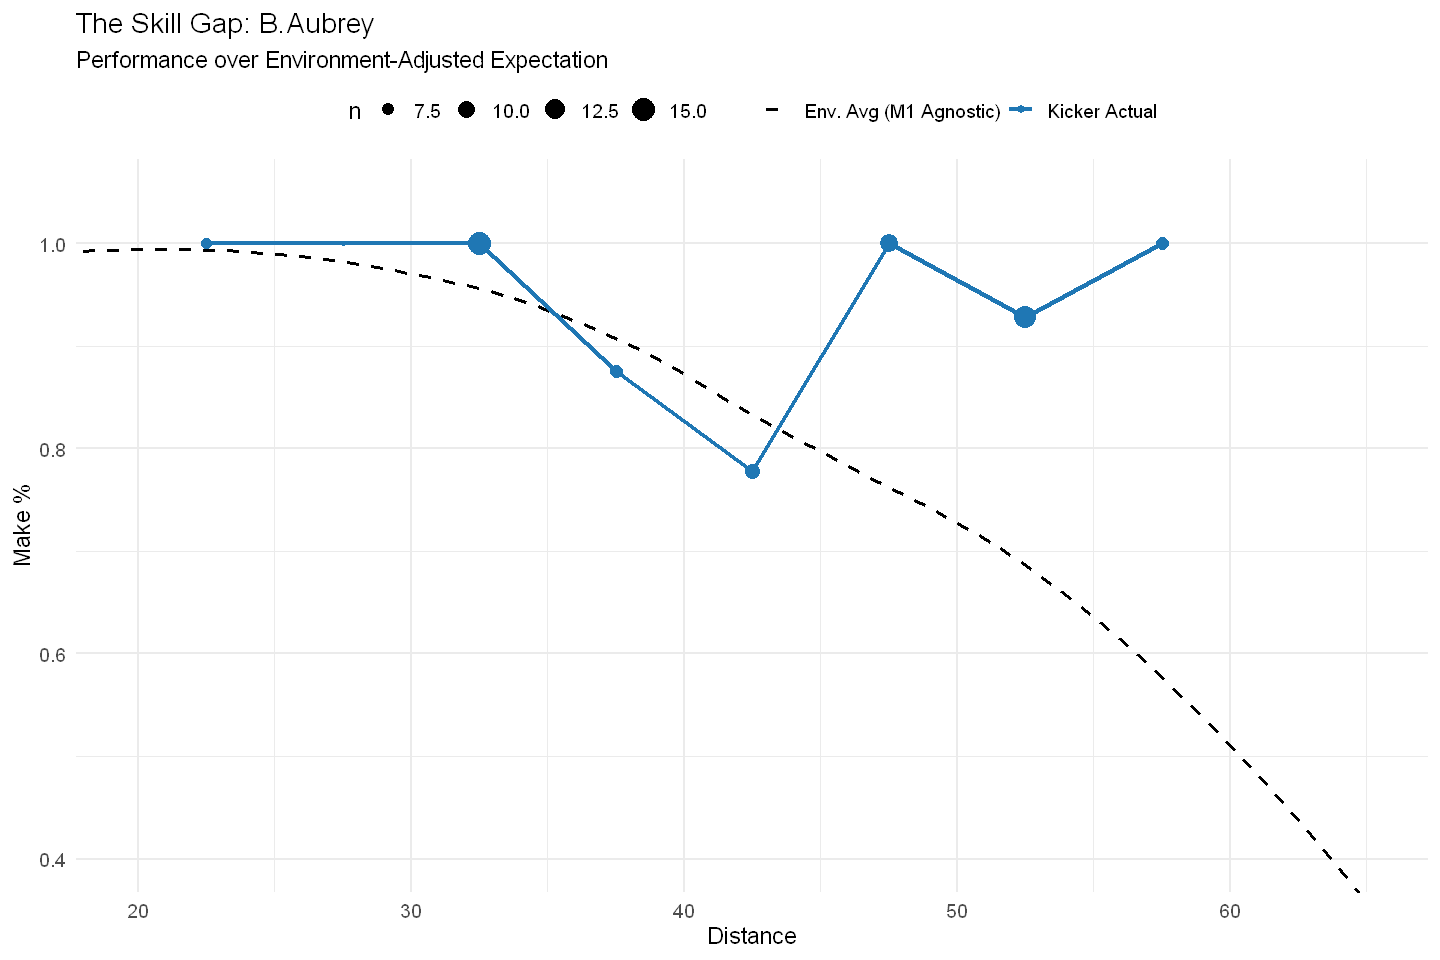

In [48]:


# ==============================================================================
# 3. Calculate Skill Metrics (Agnostic Basis)
# ==============================================================================

# Ensure Names
if(!"kicker_player_name" %in% names(fg_full_pooled)) fg_full_pooled$kicker_player_name <- fg_full_pooled$kicker_player_id

kicker_skill_agnostic <- fg_full_pooled %>%
  dplyr::group_by(kicker_player_name) %>%
  dplyr::summarise(
    Seasons = n_distinct(season),
    Attempts = n(),
    Actual_Makes = sum(kick_made),
    
    # Expectation: M1 Agnostic (Env adjusted, Kicker neutral)
    Exp_Makes_Agnostic = sum(p_m1_agnostic),
    
    # The Metric: FGOE (Skill over Environment)
    FGOE_Total = Actual_Makes - Exp_Makes_Agnostic,
    FGOE_Per_Kick = FGOE_Total / Attempts,
    
    # Context
    Avg_Distance = mean(kick_distance),
    Actual_Pct = mean(kick_made),
    Exp_Pct_Ag = mean(p_m1_agnostic),
    
    .groups = "drop"
  ) %>%
  dplyr::filter(Attempts >= 50) %>%
  dplyr::arrange(desc(FGOE_Per_Kick))

cat("\n--- Top 10 Kickers by True Skill (Environment Adjusted FGOE) ---\n")
print(head(kicker_skill_agnostic, 10))

# Check the Aubrey Effect again (Did removing Kicker ID restore his value?)
cat("\n--- The Aubrey Check (Agnostic Baseline) ---\n")
print(kicker_skill_agnostic %>% filter(kicker_player_name == "B.Aubrey"))

# ==============================================================================
# 4. Visualizations
# ==============================================================================

# A. Leaderboard
top_kickers <- head(kicker_skill_agnostic, 10)
bottom_kickers <- tail(kicker_skill_agnostic, 5)
plot_leaderboard <- bind_rows(top_kickers, bottom_kickers) %>%
  mutate(
    Color = ifelse(FGOE_Per_Kick > 0, "#2ca02c", "#d62728"),
    Label = paste0(kicker_player_name, " (", round(FGOE_Per_Kick*100, 1), "%)")
  )

p_rank_ag <- ggplot(plot_leaderboard, aes(x = reorder(kicker_player_name, FGOE_Per_Kick), y = FGOE_Per_Kick, fill = Color)) +
  geom_bar(stat = "identity", color = "black", alpha = 0.8) +
  coord_flip() +
  scale_fill_identity() +
  scale_y_continuous(labels = scales::percent) +
  labs(
    title = "True Kicker Skill: FGOE (Environment Adjusted)",
    subtitle = "Baseline: M1 Agnostic (Distance + Weather + Stadium + Season, No Kicker ID)",
    x = "Kicker", y = "Performance vs. Env. Expectation"
  ) +
  theme_minimal(base_size = 14)

# B. Scatter (Skill vs Difficulty)
p_scatter_ag <- ggplot(kicker_skill_agnostic, aes(x = Avg_Distance, y = FGOE_Per_Kick)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey") +
  geom_point(aes(size = Attempts, color = FGOE_Per_Kick), alpha = 0.8) +
  ggrepel::geom_text_repel(data = plot_leaderboard, aes(label = kicker_player_name), size = 4) +
  scale_color_gradient2(low = "#d62728", mid = "grey90", high = "#2ca02c", midpoint = 0) +
  scale_y_continuous(labels = scales::percent) +
  labs(
    title = "True Skill vs. Workload",
    subtitle = "Does high skill correlate with difficult assignments?",
    x = "Avg Distance", y = "FGOE % (Env Adj)"
  ) +
  theme_minimal(base_size = 14) + theme(legend.position = "none")

# C. The GOAT Curve (Specific Kicker vs Agnostic Baseline)
goat_id <- kicker_skill_agnostic$kicker_player_name[1] # Top ranked

goat_data <- fg_full_pooled %>% 
  filter(kicker_player_name == goat_id) %>%
  mutate(bin = floor(kick_distance/5)*5) %>%
  group_by(bin) %>%
  summarise(n = n(), obs_rate = mean(kick_made), exp_rate = mean(p_m1_agnostic)) %>%
  filter(n >= 5)

league_curve <- fg_full_pooled %>%
  select(kick_distance, p_m1_agnostic) %>%
  rename(Prob = p_m1_agnostic)

p_curve_ag <- ggplot() +
  geom_smooth(data = league_curve, aes(x = kick_distance, y = Prob, color = "Env. Avg (M1 Agnostic)"), 
              method = "loess", linetype = "dashed", size = 1, se = FALSE) +
  geom_line(data = goat_data, aes(x = bin + 2.5, y = obs_rate, color = "Kicker Actual"), size = 1.2) +
  geom_point(data = goat_data, aes(x = bin + 2.5, y = obs_rate, size = n, color = "Kicker Actual")) +
  scale_color_manual(values = c("Env. Avg (M1 Agnostic)" = "black", "Kicker Actual" = "#1f77b4")) +
  coord_cartesian(ylim = c(0.4, 1.05), xlim = c(20, 65)) +
  labs(
    title = paste0("The Skill Gap: ", goat_id),
    subtitle = "Performance over Environment-Adjusted Expectation",
    x = "Distance", y = "Make %", color = ""
  ) +
  theme_minimal(base_size = 14) + theme(legend.position = "top")

# Display
options(repr.plot.width = 12, repr.plot.height = 8)
print(p_rank_ag)
print(p_scatter_ag)
print(p_curve_ag)


--- Top 10 Kickers by Skill (FGOE vs M2 IPW) ---
# A tibble: 10 × 11
   kicker_player_name Seasons Attempts Actual_Makes Exp_Makes_M2 Exp_Pct_M2
   <chr>                <int>    <int>        <int>        <dbl>      <dbl>
 1 J.Tucker                10      368          332        315.       0.857
 2 J.Sanders                7      218          190        184.       0.843
 3 C.Boswell               10      321          289        280.       0.873
 4 G.Gano                   9      249          221        215.       0.862
 5 N.Folk                   9      230          207        202.       0.878
 6 B.Grupe                  2       67           57         55.6      0.830
 7 C.Dicker                 3      102           96         94.0      0.921
 8 J.Elliott                8      255          222        217.       0.852
 9 J.Lambo                  7      150          132        129.       0.862
10 A.Vinatieri              5      142          121        119.       0.835
   FGOE_Total FGOE

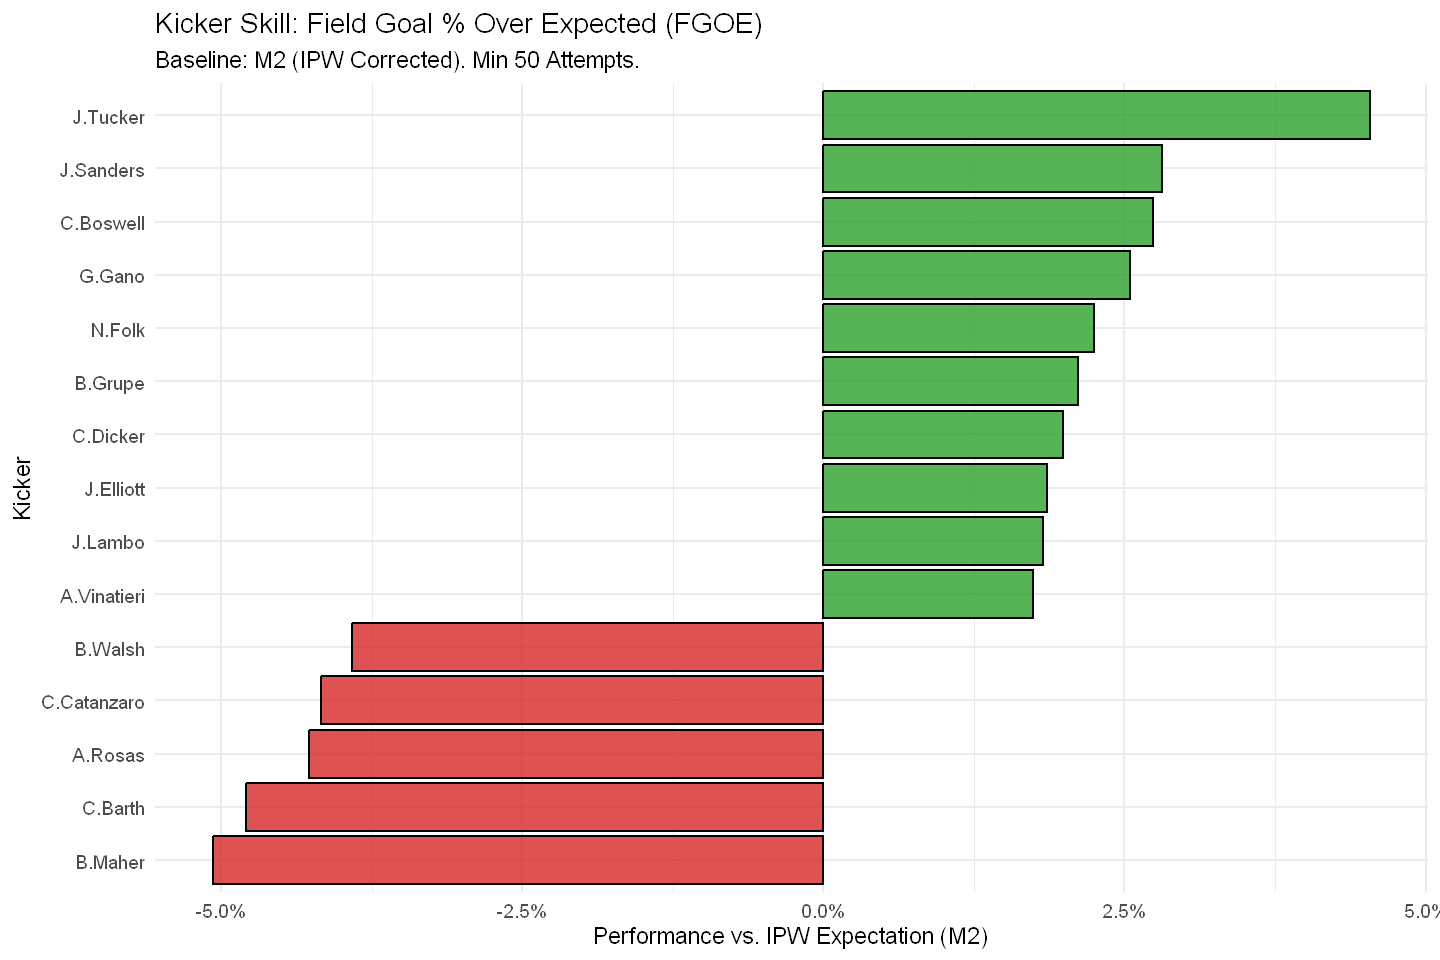

`geom_smooth()` using formula = 'y ~ x'


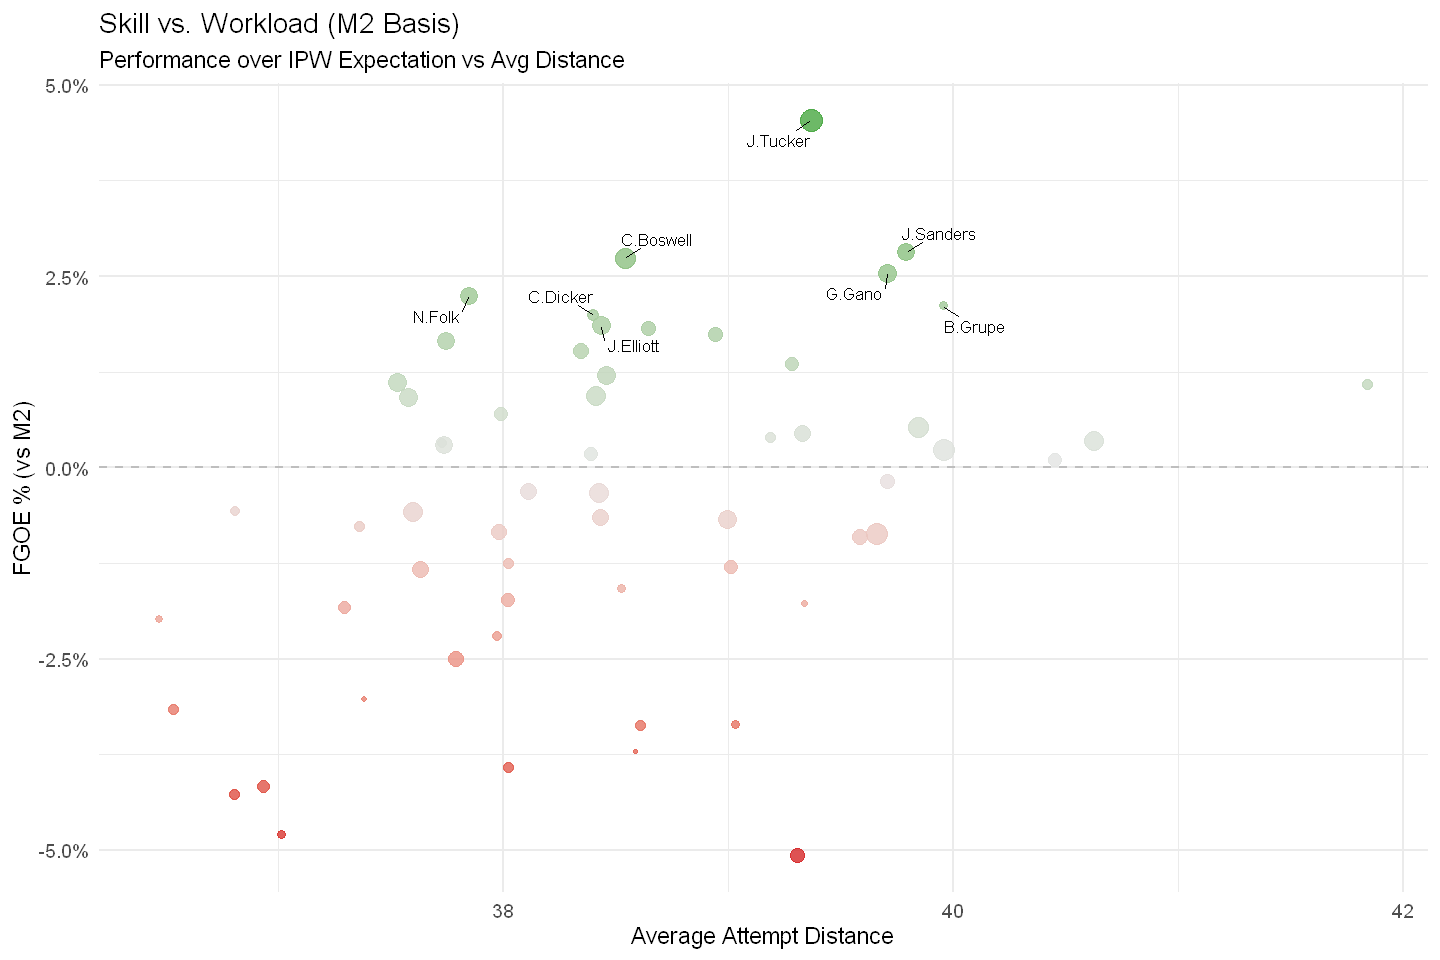

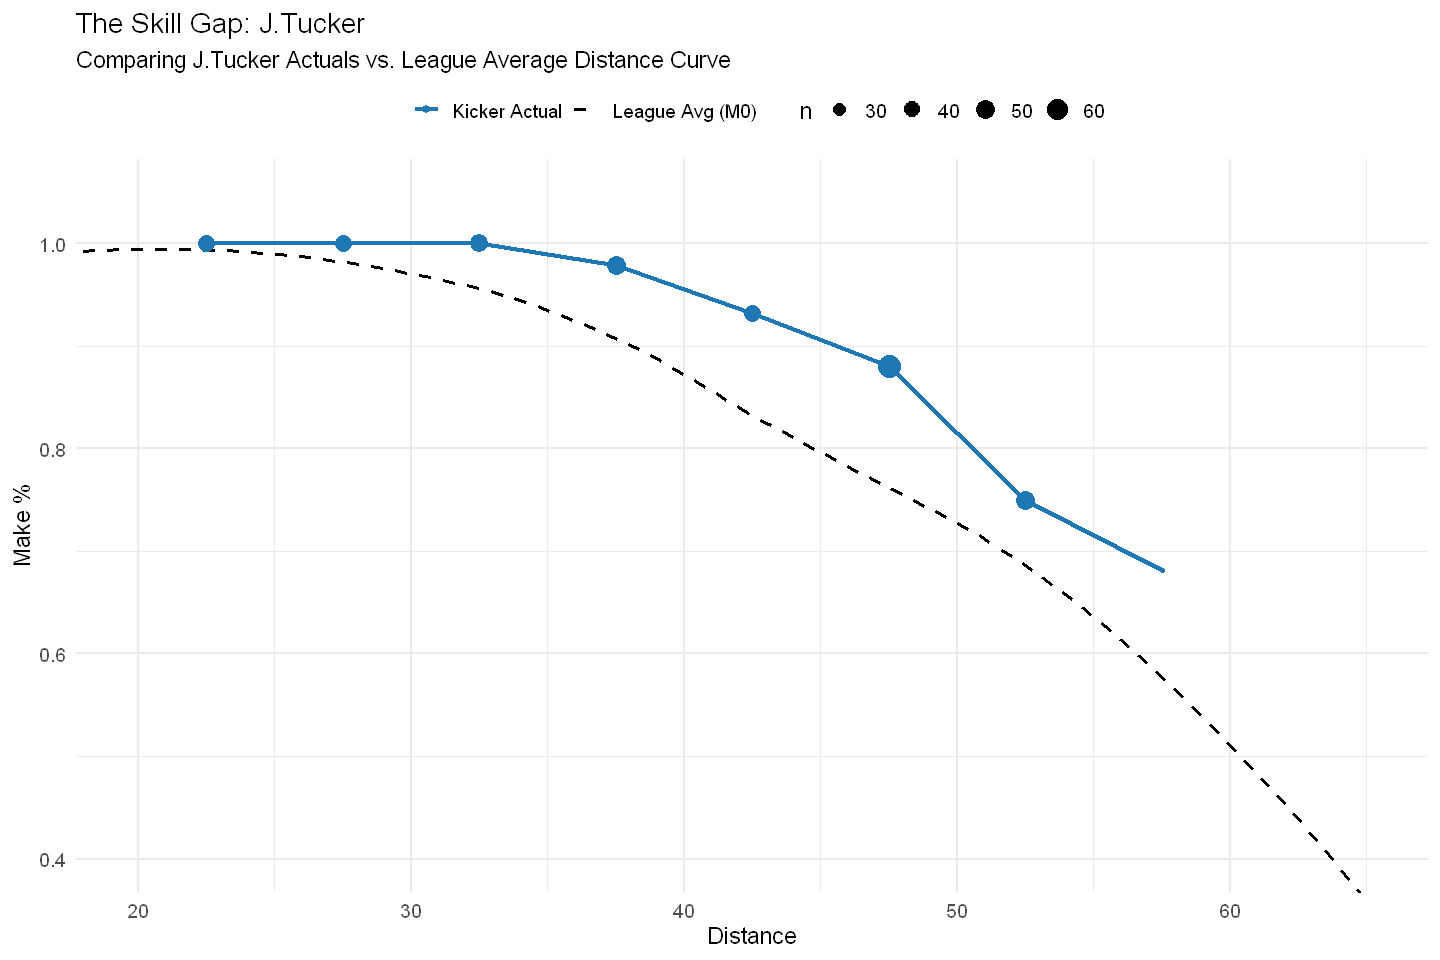

In [56]:

# ==============================================================================
# 1. Data Prep: Bind Predictions & Calculate FGOE
# ==============================================================================

# CRITICAL STEP: Ensure both M0 (Reference) and M2 (Metric) probabilities exist
fg_skill_data_m2 <- fg_full_pooled %>%
  dplyr::mutate(
    # Bind M2 predictions (The Basis for this specific analysis)
    p_m2 = if(exists("p_m2_full")) p_m2_full else pred_m2_full,
    # Bind M0 predictions (For the "League Average" curve visual)
    p_m0 = if(exists("p_m0_full")) p_m0_full else pred_m0_full
  )

# Handle Names: Use ID if Name doesn't exist
if(!"kicker_player_name" %in% names(fg_skill_data_m2)) {
  fg_skill_data_m2$kicker_player_name <- fg_skill_data_m2$kicker_player_id
}

# Calculate Skill Metrics
kicker_skill_m2 <- fg_skill_data_m2 %>%
  dplyr::group_by(kicker_player_name) %>%
  dplyr::summarise(
    Seasons = n_distinct(season),
    Attempts = n(),
    
    # Metric Components
    Actual_Makes = sum(kick_made),
    
    # Expectation based on M2 (IPW Model)
    # This calculates: "Did you make more kicks than the IPW model expected?"
    Exp_Makes_M2 = sum(p_m2), 
    Exp_Pct_M2 = mean(p_m2),
    
    # The Metric: FGOE (vs M2)
    FGOE_Total = Actual_Makes - Exp_Makes_M2,
    FGOE_Per_Kick = FGOE_Total / Attempts,
    
    # Context columns
    Avg_Distance = mean(kick_distance),
    Actual_Pct = mean(kick_made),
    Exp_Pct_M0 = mean(p_m0), # Keep M0 for context/comparison
    
    .groups = "drop"
  ) %>%
  # Filter for sample size (min 50 attempts)
  dplyr::filter(Attempts >= 50) %>%
  dplyr::arrange(desc(FGOE_Per_Kick))

cat("\n--- Top 10 Kickers by Skill (FGOE vs M2 IPW) ---\n")
print(head(kicker_skill_m2, 10))

# ==============================================================================
# 2. Visual 1: The Skill Leaderboard (Bar Chart)
# ==============================================================================

# Select Top 10 and Bottom 5
top_kickers_m2 <- head(kicker_skill_m2, 10)
bottom_kickers_m2 <- tail(kicker_skill_m2, 5)
plot_leaderboard_m2 <- bind_rows(top_kickers_m2, bottom_kickers_m2) %>%
  mutate(
    Color = ifelse(FGOE_Per_Kick > 0, "#2ca02c", "#d62728"), # Green/Red
    Label = paste0(kicker_player_name, " (", round(FGOE_Per_Kick*100, 1), "%)")
  )

p_rank_2 <- ggplot(plot_leaderboard_m2, aes(x = reorder(kicker_player_name, FGOE_Per_Kick), y = FGOE_Per_Kick, fill = Color)) +
  geom_bar(stat = "identity", color = "black", alpha = 0.8) +
  coord_flip() +
  scale_fill_identity() +
  scale_y_continuous(labels = scales::percent) +
  labs(
    title = "Kicker Skill: Field Goal % Over Expected (FGOE)",
    subtitle = "Baseline: M2 (IPW Corrected). Min 50 Attempts.",
    x = "Kicker",
    y = "Performance vs. IPW Expectation (M2)"
  ) +
  theme_minimal(base_size = 14)

# ==============================================================================
# 3. Visual 2: Skill vs. Difficulty (Scatter)
# ==============================================================================

p_scatter_2 <- ggplot(kicker_skill_m2, aes(x = Avg_Distance, y = FGOE_Per_Kick)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey") +
  geom_point(aes(size = Attempts, color = FGOE_Per_Kick), alpha = 0.8) +
  # Label top performers from the leaderboard
  ggrepel::geom_text_repel(
    data = head(kicker_skill_m2, 8), 
    aes(label = kicker_player_name), 
    size = 3.5, box.padding = 0.5
  ) +
  scale_color_gradient2(low = "#d62728", mid = "grey90", high = "#2ca02c", midpoint = 0) +
  scale_y_continuous(labels = scales::percent) +
  labs(
    title = "Skill vs. Workload (M2 Basis)",
    subtitle = "Performance over IPW Expectation vs Avg Distance",
    x = "Average Attempt Distance",
    y = "FGOE % (vs M2)"
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "none")

# ==============================================================================
# 4. Visual 3: The "GOAT" Curve (Visualizing Skill)
# ==============================================================================

# Identify the #1 Kicker
goat_id_2 <- kicker_skill_m2 %>% arrange(desc(FGOE_Total)) %>% slice(1) %>% pull(kicker_player_name)

# Get GOAT's Data (Binned)
goat_data_2 <- fg_skill_data_m2 %>% 
  filter(kicker_player_name == goat_id_2) %>%
  mutate(bin = floor(kick_distance/5)*5) %>%
  group_by(bin) %>%
  summarise(
    n = n(),
    obs_rate = mean(kick_made), 
    # We plot against M0 (Distance Avg) to show the visual "lift" over standard expectation
    exp_rate_m0 = mean(p_m0) 
  ) %>%
  filter(n >= 5)

# Get League Average Curve (M0)
league_curve <- fg_skill_data_m2 %>%
  select(kick_distance, p_m0) %>%
  rename(Prob = p_m0)

p_curve_2 <- ggplot() +
  # A. League Average Line (M0 - Distance Only)
  geom_smooth(data = league_curve, aes(x = kick_distance, y = Prob, color = "League Avg (M0)"), 
              method = "loess", linetype = "dashed", size = 1, se = FALSE) +
  # B. The Kicker's Actual Performance
  geom_line(data = goat_data_2, aes(x = bin + 2.5, y = obs_rate, color = "Kicker Actual"), size = 1.2) +
  geom_point(data = goat_data_2, aes(x = bin + 2.5, y = obs_rate, size = n, color = "Kicker Actual")) +
  # Colors
  scale_color_manual(values = c("League Avg (M0)" = "black", "Kicker Actual" = "#1f77b4")) +
  coord_cartesian(ylim = c(0.4, 1.05), xlim = c(20, 65)) +
  labs(
    title = paste0("The Skill Gap: ", goat_id_2),
    subtitle = paste0("Comparing ", goat_id_2, " Actuals vs. League Average Distance Curve"),
    x = "Distance", y = "Make %", color = ""
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "top")

# ==============================================================================
# 5. Display Plots
# ==============================================================================

options(repr.plot.width = 12, repr.plot.height = 8)
print(p_rank_2)
print(p_scatter_2)
print(p_curve_2)

In [57]:
kicker_skill_m2 %>% arrange(desc(Exp_Pct_M2)) %>% head(10)

kicker_player_name,Seasons,Attempts,Actual_Makes,Exp_Makes_M2,Exp_Pct_M2,FGOE_Total,FGOE_Per_Kick,Avg_Distance,Actual_Pct,Exp_Pct_M0
<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
C.Dicker,3,102,96,93.96834,0.9212582,2.0316618,0.019918253,38.40196,0.9411765,0.8621024
B.Aubrey,2,83,77,76.09231,0.9167748,0.9076921,0.010936050,41.84337,0.9277108,0.8084220
H.Butker,8,284,254,255.64218,0.9001485,-1.6421807,-0.005782326,37.59859,0.8943662,0.8722287
R.Gould,8,251,227,224.68795,0.8951711,2.3120492,0.009211351,37.57769,0.9043825,0.8749145
M.Wright,5,63,55,55.99515,0.8888119,-0.9951493,-0.015796021,38.52381,0.8730159,0.8642268
K.Forbath,6,88,77,78.09872,0.8874854,-1.0987183,-0.012485435,38.02273,0.8750000,0.8669703
C.Catanzaro,4,109,92,96.54667,0.8857493,-4.5466717,-0.041712585,36.93578,0.8440367,0.8773944
Y.Koo,7,204,179,180.33567,0.8839984,-1.3356727,-0.006547415,38.43137,0.8774510,0.8647235
C.McLaughlin,6,150,132,132.26574,0.8817716,-0.2657361,-0.001771574,39.70667,0.8800000,0.8450763
